# 목표

뉴스의 카테고리 예측

In [1]:
# %load_ext colablinter

# 데이터 파악

In [2]:
# 시각화, 디바이스 등 기본 설정

import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc
import os


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


# # 로그
# import logging

# def init_logger() -> logging.Logger:
#     logging.basicConfig(
#         format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
#         datefmt="%Y-%m-%d %H:%M:%S",
#         level=logging.INFO,
#         encoding="utf-8",
#     )
#     return logging.getLogger("")

# logger = init_logger()

Matplotlib is building the font cache; this may take a moment.


In [3]:
ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "data")
TRAIN_DIR = os.path.join(DATA_DIR, "20news-bydate-train")
TEST_DIR = os.path.join(DATA_DIR, "20news-bydate-test")

In [4]:
# 파일 개수 세기
from glob import glob

train_category_list = os.listdir(TRAIN_DIR)
test_category_list = os.listdir(TEST_DIR)

train_path_list = [path_ for path_ in glob(os.path.join(TRAIN_DIR, "**", "**")) 
               if os.path.isfile(path_) and not path_.endswith(".DS_Store")]
test_path_list = [path_ for path_ in glob(os.path.join(TEST_DIR, "**", "**")) 
              if os.path.isfile(path_) and not path_.endswith(".DS_Store")]

print(f"· 학습 데이터: {len(train_path_list)}개")
print(f"· 테스트 데이터: {len(test_path_list)}개")

· 학습 데이터: 11314개
· 테스트 데이터: 7532개


In [5]:
import chardet
from collections import Counter

def detect_encoding(file_path):
    """파일의 인코딩을 감지"""
    with open(file_path, 'rb') as f:
        raw_data = f.read()
    result = chardet.detect(raw_data)
    return result['encoding'], result['confidence']

# 모든 파일의 인코딩 정보 수집
encoding_info = {}
encoding_counter = Counter()

all_paths = train_path_list + test_path_list

for i, path in enumerate(all_paths):   
    try:
        encoding, confidence = detect_encoding(path)
        encoding_info[path] = {'encoding': encoding, 'confidence': confidence}
        encoding_counter[encoding] += 1
    except Exception as e:
        print(f"오류 발생 ({path}): {e}")

print("[인코딩 분포]")
for encoding, count in encoding_counter.most_common():
    percentage = (count / len(all_paths)) * 100
    print(f"· {encoding}: {count}개 ({percentage:.2f}%)")

[인코딩 분포]
· ascii: 18767개 (99.58%)
· ISO-8859-1: 58개 (0.31%)
· Windows-1252: 7개 (0.04%)
· MacRoman: 6개 (0.03%)
· None: 3개 (0.02%)
· HZ-GB-2312: 2개 (0.01%)
· Johab: 1개 (0.01%)
· ISO-2022-JP: 1개 (0.01%)
· ISO-8859-7: 1개 (0.01%)


In [6]:
def get_text(path):
    """감지된 인코딩으로 파일 읽기"""
    # encoding_info에 정보가 있으면 사용
    encoding = encoding_info.get(path, {}).get('encoding', 'latin-1')
    
    # None이면 latin-1 사용 (모든 바이트값을 읽을 수 있음)
    if encoding is None:
        encoding = 'latin-1'
    
    try:
        with open(path, "r", encoding=encoding) as f:
            return f.read()
    except:
        # 실패시 latin-1로 폴백 (절대 실패하지 않음)
        with open(path, "r", encoding="latin-1") as f:
            return f.read()

In [7]:
# 비어 있는 내용 텍스트 점검
for path_ in all_paths:
    if len(get_text(path)) < 5:
        print(True)

In [8]:
train_num_list = [path_.split("/")[-1] for path_ in train_path_list]
test_num_list = [path_.split("/")[-1] for path_ in test_path_list]

intersection = set(train_num_list) & set(test_num_list)

print(f"· 학습 - 테스트 데이터 겹치는 번호: {len(intersection)}개")

· 학습 - 테스트 데이터 겹치는 번호: 1294개


In [9]:
print("[겹치는 번호 오류 점검]")

train_dup_dict = {path_.split("/")[-1]: path_.split("/")[-2] for path_ in train_path_list 
               if path_.split("/")[-1] in intersection}

test_dup_dict = {path_.split("/")[-1]: path_.split("/")[-2] for path_ in test_path_list
               if path_.split("/")[-1] in intersection}


dup_path_list = []

for file_num in intersection:
    train_path = os.path.join(TRAIN_DIR, train_dup_dict[file_num], file_num)
    test_path = os.path.join(TEST_DIR, test_dup_dict[file_num], file_num)

    train_intersection = get_text(train_path).strip()
    test_intersection = get_text(test_path).strip()

    if train_intersection == test_intersection:
        dup_path_list.append(train_path)

print(f"· 내용 같은 파일: {len(dup_path_list)}개")

[겹치는 번호 오류 점검]
· 내용 같은 파일: 0개


단순히 번호만 겹쳤던 것으로 확인된다.

In [10]:
train_category_set = set(train_category_list)
test_category_set = set(test_category_list)

only_in_train = train_category_set - test_category_set
only_in_test = test_category_set - train_category_set

print("[카테고리 결손 파악]")
print(f"· 학습 데이터에만 있는 카테고리: {len(only_in_train)}개")
print(f"· 테스트 데이터에만 있는 카테고리: {len(only_in_test)}개")

[카테고리 결손 파악]
· 학습 데이터에만 있는 카테고리: 0개
· 테스트 데이터에만 있는 카테고리: 0개


In [11]:
CATEGORY_LIST = os.listdir(TRAIN_DIR)

CATEGORY_LIST.remove(".DS_Store")

In [12]:
print("[카테고리별 데이터 개수]")
i = 0

for category in CATEGORY_LIST:

    i += 1
    path_list = [path_ for path_ in glob(os.path.join(TRAIN_DIR, category, "*")) 
                 if os.path.isfile(path_) and not path_.endswith(".DS_Store")]
    
    print(f"{i}) {category}: {len(path_list)}개")

[카테고리별 데이터 개수]
1) talk.politics.mideast: 564개
2) rec.autos: 594개
3) comp.sys.mac.hardware: 578개
4) alt.atheism: 480개
5) rec.sport.baseball: 597개
6) comp.os.ms-windows.misc: 591개
7) rec.sport.hockey: 600개
8) sci.crypt: 595개
9) sci.med: 594개
10) talk.politics.misc: 465개
11) rec.motorcycles: 598개
12) comp.windows.x: 593개
13) comp.graphics: 584개
14) comp.sys.ibm.pc.hardware: 590개
15) sci.electronics: 591개
16) talk.politics.guns: 546개
17) sci.space: 593개
18) soc.religion.christian: 599개
19) misc.forsale: 585개
20) talk.religion.misc: 377개


- talk.religion.misc 카테고리가 비교적 적다.

- 상위 하위 카테고리로 구성되어 있으니, 카테고리도 더 나눠볼 필요가 있다.

- misc는 잡동사니라는 뜻으로, 주요 카테고리가 아니라는 뜻이다.

    - misc가 아닌 카테고리는 main으로 분류한다.

In [13]:
TRAIN_DICT = dict()

for category in CATEGORY_LIST:
    for path_ in glob(os.path.join(TRAIN_DIR, category, "*")):

        if os.path.isfile(path_) and not path_.endswith(".DS_Store"):
            
            TRAIN_DICT[path_] = dict()
            TRAIN_DICT[path_]["category"] = category

            split_category = category.split(".")
            if split_category[-1] != "misc":
                split_category.append("main")

            for i, split in enumerate(split_category):
                if split == "main":
                    TRAIN_DICT[path_][5] = "main"
                    
                elif split == "misc" and i != 0:
                    TRAIN_DICT[path_][5] = "misc"

                else:
                    TRAIN_DICT[path_][i] = split

In [14]:
print("[TRAIN_DICT 예시 출력]")
for key, value in TRAIN_DICT.items():
    print(key, "\n: ", value)
    break

[TRAIN_DICT 예시 출력]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.mideast/75895 
:  {'category': 'talk.politics.mideast', 0: 'talk', 1: 'politics', 2: 'mideast', 5: 'main'}


In [15]:
# import json

# train_json_path = os.path.join(DATA_DIR, "train.json")

# with open(train_json_path, "w", encoding="utf-8") as f:
#     json.dump(TRAIN_DICT, f, indent=4)


# test_json_path = os.path.join(DATA_DIR, "test.json")

# with open(test_json_path, "w", encoding="utf-8") as f:
#     json.dump(TEST_DICT, f, indent=4)

In [16]:
count_by_category_dict = {i: dict() for i in range(6)}

for category_dict in TRAIN_DICT.values():
    for key, value in category_dict.items():
        if key != "category":
            if value not in count_by_category_dict[key].keys():
                count_by_category_dict[key][value] = 1
            else:
                count_by_category_dict[key][value] += 1

In [17]:
# 카테고리를 노드 구조로 시각화

import plotly.graph_objects as go

# 데이터
data = count_by_category_dict

nodes_by_level_and_name = {}
nodes = {}
edges = set()
node_id = 0

root_key = ('ROOT', 0)
nodes[root_key] = {'id': node_id, 'label': 'ROOT', 'level': 0, 'count': len(TRAIN_DICT)}
nodes_by_level_and_name[(0, 'ROOT')] = root_key
node_id += 1

for level, name_count_dict in data.items():
    current_level = level + 1
    for name, count in name_count_dict.items():
        node_key = (name, current_level)
        if node_key not in nodes:
            nodes[node_key] = {
                'id': node_id,
                'label': name,
                'level': current_level,
                'count': count,
            }
            nodes_by_level_and_name[(current_level, name)] = node_key
            node_id += 1

for _, category_dict in TRAIN_DICT.items():
    ordered_path = sorted(
        (int(k), v) for k, v in category_dict.items() if k != 'category'
    )
    parent_key = root_key
    for level_idx, name in ordered_path:
        current_level = level_idx + 1
        node_key = nodes_by_level_and_name.get((current_level, name))
        if node_key is None:
            continue
        edges.add((parent_key, node_key))
        parent_key = node_key

levels = {}
for node_key, node in nodes.items():
    levels.setdefault(node['level'], []).append(node_key)


# 노드의 최대 자식 깊이를 계산하는 함수
def get_max_depth(node_key, edges, memo=None):
    """
    해당 노드에서 시작하여 도달할 수 있는 최대 깊이를 반환합니다.
    """
    if memo is None:
        memo = {}
    
    if node_key in memo:
        return memo[node_key]
    
    # 자식 노드 찾기
    children = [child for parent, child in edges if parent == node_key]
    
    if not children:
        memo[node_key] = 0
        return 0
    
    # 자식들의 최대 깊이 + 1
    max_child_depth = max(get_max_depth(child, edges, memo) for child in children)
    memo[node_key] = max_child_depth + 1
    
    return memo[node_key]


# 부모-자식 관계를 기반으로 노드 정렬 함수
def sort_nodes_by_hierarchy(node_keys, edges, nodes):
    """
    부모-자식 관계를 고려하여 노드를 정렬합니다.
    깊이가 깊은 노드를 왼쪽에 배치하고 (레벨 5 제외),
    같은 부모를 가진 노드들끼리 그룹화합니다.
    """
    if not node_keys:
        return []
    
    # 각 노드의 부모들 찾기
    node_parents = {}
    for parent, child in edges:
        if child in node_keys:
            if child not in node_parents:
                node_parents[child] = []
            node_parents[child].append(parent)
    
    # 부모가 없는 노드들 (루트 레벨)
    if not node_parents:
        return sorted(node_keys, key=lambda x: nodes[x]['label'])
    
    # 각 노드의 최대 깊이 계산
    depth_memo = {}
    for node_key in node_keys:
        get_max_depth(node_key, edges, depth_memo)
    
    # 부모별로 자식 노드 그룹화
    parent_to_children = {}
    for node in node_keys:
        parents = tuple(sorted(node_parents.get(node, [])))
        if parents not in parent_to_children:
            parent_to_children[parents] = []
        parent_to_children[parents].append(node)
    
    # 각 그룹 내에서 정렬
    # 레벨 5가 아니면: 깊이가 깊은 것 -> 알파벳순
    # 레벨 5이면: 알파벳순만
    for parents in parent_to_children:
        children = parent_to_children[parents]
        current_level = nodes[children[0]]['level']
        
        if current_level == 6:  # 레벨 5 (0-indexed이므로 6)
            # 레벨 5는 알파벳순으로만 정렬
            parent_to_children[parents].sort(key=lambda x: nodes[x]['label'])
        else:
            # 다른 레벨은 깊이 우선 -> 알파벳순
            parent_to_children[parents].sort(
                key=lambda x: (-depth_memo.get(x, 0), nodes[x]['label'])
            )
    
    # 부모의 x 좌표 순서대로 자식들을 배치
    sorted_nodes = []
    
    # 첫 번째 레벨은 부모의 x 좌표가 없으므로 깊이 -> 알파벳순으로
    if all(p not in nodes or 'x' not in nodes[p] for parents in parent_to_children.keys() for p in parents):
        sorted_parent_groups = sorted(
            parent_to_children.keys(),
            key=lambda parents: (
                -max(depth_memo.get(child, 0) for child in parent_to_children[parents]),
                min(nodes[child]['label'] for child in parent_to_children[parents])
            )
        )
    else:
        # 부모의 x 좌표를 기준으로 정렬
        def get_parent_x(parents):
            if not parents:
                return 0
            parent_xs = [nodes[p].get('x', 0) for p in parents if p in nodes]
            return sum(parent_xs) / len(parent_xs) if parent_xs else 0
        
        sorted_parent_groups = sorted(parent_to_children.keys(), key=get_parent_x)
    
    for parents in sorted_parent_groups:
        sorted_nodes.extend(parent_to_children[parents])
    
    return sorted_nodes


# 레벨별 노드 배치 (계층 구조 기반 정렬 적용)
for level, node_keys in levels.items():
    # 계층 구조 기반 정렬 적용
    sorted_node_keys = sort_nodes_by_hierarchy(node_keys, edges, nodes)
    
    num_nodes = len(sorted_node_keys)
    y = -level * 2
    for i, key in enumerate(sorted_node_keys):
        if num_nodes == 1:
            x = 0
        else:
            spacing = min(15, 50 / num_nodes)
            x = (i - (num_nodes - 1) / 2) * spacing
        nodes[key]['x'] = x
        nodes[key]['y'] = y

edge_x = []
edge_y = []
for parent, child in edges:
    edge_x.extend([nodes[parent]['x'], nodes[child]['x'], None])
    edge_y.extend([nodes[parent]['y'], nodes[child]['y'], None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode='lines',
    line=dict(width=1.5, color='#cccccc'),
    hoverinfo='none'
)

node_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
node_x = []
node_y = []
node_labels = []
node_counts = []
node_color = []
node_sizes = []

for n in nodes.values():
    node_x.append(n['x'])
    node_y.append(n['y'])
    node_labels.append(n['label'])
    node_counts.append(str(n.get('count', 0)))
    node_color.append(node_colors[n['level'] % len(node_colors)])
    base_size = 14 if n['level'] == 0 else 10
    scale = 0 if n.get('count') is None else max(0, n['count']) ** 0.5
    node_sizes.append(base_size + scale)

parent_counts = {}
for parent, child in edges:
    parent_counts[child] = parent_counts.get(child, 0) + 1

hover_text = []
for node_key, n in nodes.items():
    parent_count = parent_counts.get(node_key, 0)
    base_text = f"{n['label']}<br>레벨: {n['level']}<br>개수: {n.get('count', 0)}"
    if parent_count > 1:
        hover_text.append(base_text + f"<br>부모 노드: {parent_count}개")
    else:
        hover_text.append(base_text)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    marker=dict(
        size=node_sizes,
        color=node_color,
        line=dict(width=2, color='white')
    ),
    hoverinfo='text',
    hovertext=hover_text
)

count_text_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='text',
    text=node_counts,
    textposition='middle center',
    textfont=dict(size=10, color='white', family='Arial'),
    hoverinfo='none'
)

label_text_trace = go.Scatter(
    x=node_x,
    y=[y + 0.5 for y in node_y],
    mode='text',
    text=node_labels,
    textposition='top center',
    textfont=dict(size=10, color='black', family='Arial'),
    hoverinfo='none'
)

layout = go.Layout(
    title=dict(text='카테고리 계층 구조 (중복 노드 병합)', font=dict(size=20)),
    showlegend=False,
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    margin=dict(l=40, r=40, t=60, b=40),
    height=900,
)

fig = go.Figure(
    data=[edge_trace, node_trace, count_text_trace, label_text_trace],
    layout=layout,
)
fig.show()


In [18]:
sub_category_list = list()
for category in CATEGORY_LIST:
    sub_category_list.extend(category.split(".")[1:])


multi_list = list()
for sub_category in set(sub_category_list):
    if sub_category_list.count(sub_category) > 1:
        multi_list.append(sub_category)


multi_dict = dict()
for category in CATEGORY_LIST:
    for multi_class in multi_list:
        if multi_class in category.split(".")[1:]:
            if multi_class in multi_dict.keys():
                multi_dict[multi_class].append(category)
            else:
                multi_dict[multi_class] = [category]


print("[여러 요소가 있는 카테고리]")
for key, value in multi_dict.items():
    print(f"· {key}: {value}")

[여러 요소가 있는 카테고리]
· politics: ['talk.politics.mideast', 'talk.politics.misc', 'talk.politics.guns']
· hardware: ['comp.sys.mac.hardware', 'comp.sys.ibm.pc.hardware']
· sys: ['comp.sys.mac.hardware', 'comp.sys.ibm.pc.hardware']
· sport: ['rec.sport.baseball', 'rec.sport.hockey']
· misc: ['comp.os.ms-windows.misc', 'talk.politics.misc', 'talk.religion.misc']
· religion: ['soc.religion.christian', 'talk.religion.misc']


1. 각 카테고리를 합쳤을 때는 불균형이 그렇게 심하게 보이지 않지만, 쪼개서 노드로 보니 결과가 다르다.

2. religion이라는 카테고리는 2개의 메인 카테고리에 딸려 있어 복잡하다. 계속 주시해야 하는 파트라는 생각이 든다.

3. 가장 하위 카테고리가 misc인 카테고리와 아닌 카테고리가 있는데 그것들만을 기준으로 보면 불균형은 아주 심하다.

4. hardware는 다른 깊이에 존재한다.

# 실험 계획

1. 주 카테고리부터 한 단계씩 밑으로 내려가며 학습. 각 단계마다 카테고리 불균형 해소 진행.

2. 주 카테고리와 가장 하위 카테고리(main, misc 제외) 학습

3. 그냥 한 번에 학습

카테고리 자체를 RNN처럼 시퀀셜로 학습할 수 있을까?

이 세 개로 나누어서 비교한다.

# 데이터 전처리 

## 1. 테스트 데이터 형식 조정

In [19]:
TEST_DICT = dict()

for category in CATEGORY_LIST:
    for path_ in glob(os.path.join(TEST_DIR, category, "*")):

        if os.path.isfile(path_):
            
            TEST_DICT[path_] = dict()
            TEST_DICT[path_]["category"] = category

            split_category = category.split(".")
            if split_category[-1] != "misc":
                split_category.append("main")

            for i in range(0, len(split_category)):
                TEST_DICT[path_][i] = split_category[i]


for _, dictionary in TEST_DICT.items():
    for i in range(1, len(dictionary) - 1):
        if dictionary[i] == "main":
            dictionary[5] = "main"
            del dictionary[i]
            continue

        elif dictionary[i] == "misc":
            dictionary[5] = "misc"
            del dictionary[i]

## 2. 텍스트 정제

In [20]:
import random

rand_idx = random.randint(1, len(TRAIN_DICT.keys()))
rand_key = list(TRAIN_DICT.keys())[rand_idx]

sample_key = rand_key.split("/")[-2]
sample_text = get_text(rand_key)

print(f"[샘플 출력]")
print(f"· 카테고리: {sample_key}")
print("· 본문", "="*40)
print(sample_text)

[샘플 출력]
· 카테고리: rec.autos
· 본문 ========================================
From: aas7@po.CWRU.Edu (Andrew A. Spencer)
Subject: Re: MR2 - noisy engine.
Organization: Case Western Reserve University, Cleveland, OH (USA)
Lines: 33
Reply-To: aas7@po.CWRU.Edu (Andrew A. Spencer)
NNTP-Posting-Host: slc5.ins.cwru.edu


In a previous article, eliot@lanmola.engr.washington.edu (eliot) says:

>In article <1r1vofINN871@usenet.pa.dec.com> tomacj@opco.enet.dec.com (THUNDERBIRDS ARE GO !!!) writes:
>>	Are there any MR2 owners or motor-head gurus out there, that know why
>>my MR2's engine sounds noisy? The MR2's engine is noisy at the best of times, 
>>but not even a nice nose - it's one of those very ugly noises. 
>
>assuming yours is a non turbo MR2, the gruffness is characteristic of
>a large inline 4 that doesn't have balance shafts.  i guess toyota
>didn't care about "little" details like that when they can brag about
>the mid engine configuration and the flashy styling.
>
>myself, i automatically 

### 2-1. header, footer, 메타데이터

인용 부호는 아래의 답장 구조에서 활용하므로

현 파트에서는 제거하지 않는다.

In [21]:
import re

def preprocess_text(text):
    """
    뉴스그룹 메타데이터 제거 함수
    (인용 제거는 remove_quoted_content()에서 처리)
    """
    
    # 0. 짧은 줄 병합: 글자 수 초과로 인용 부호 없이 아래로 내려간 글자 병합
    lines = text.split('\n')
    merged_lines = []
    
    for i, line in enumerate(lines):
        stripped = line.strip()
        
        # 빈 줄 보존
        if not stripped:
            merged_lines.append(line)
            continue
        
        # 매우 짧고, 이전 줄이 마침표로 끝나지 않으면 병합
        if (len(stripped) < 10 and 
            merged_lines and 
            merged_lines[-1].strip() and
            not re.search(r'[.!?]$', merged_lines[-1])):
            merged_lines[-1] += ' ' + stripped
        else:
            merged_lines.append(line)
    
    text = '\n'.join(merged_lines)


    # 1. "In article ... writes:" 패턴 제거
    text = re.sub(r'In (article|message) <[^>]+>.*?writes?:', '', text, flags=re.IGNORECASE)
    
    # 2. "On ... wrote:" 패턴 제거
    text = re.sub(r'On .+? wrote:', '', text, flags=re.IGNORECASE)
    
    # 3. 이메일 주소 + writes 패턴 제거
    text = re.sub(r'\S+@\S+.*?writes?:', '', text, flags=re.IGNORECASE)
    
    # 4. 헤더 필드 제거
    header_fields = [
        'Lines:', 'From:', 'Organization:', 'Article-I.D.:',
        'Newsgroups:', 'Path:', 'Sender:', 'Nntp-Posting-Host:'
        'Distribution:', 'Message-ID:', 'References:',
        'NNTP-Posting-Host:', 'Date:', 'Reply-To:',
        'Keywords:', 'Summary:', 'Expires:', 'Followup-To:',
        'X-Newsreader:', 'X-Mailer:', 'Posted:', 'Xref:', 'X-UserAgent:',
        'Nntp-Posting-Host:', 'Distribution:', 'Originator:'
    ]
    for field in header_fields:
        text = re.sub(rf'^.*{re.escape(field)}.*$', '', text, flags=re.MULTILINE)
    
    # 5. Article ID 패턴 제거
    text = re.sub(r'<[^>]+@[^>]+>', '', text)
    
    # 6. 서명 블록 제거 (-- 이후)
    lines = text.split('\n')
    footer_start = len(lines)
    
    # 서명 구분선 (-- 또는 ---) 찾기
    for i in range(len(lines) - 1, -1, -1):
        stripped = lines[i].strip()
        if re.match(r'^--+\s*$', stripped) or stripped == '-- ':
            footer_start = i
            break
    
    # 구분선 없으면 역방향 스캔 (빈 줄 기반)
    if footer_start == len(lines):
        found_footer_hint = False
        
        for i in range(len(lines) - 1, -1, -1):
            stripped = lines[i].strip()
            
            # 빈 줄 만나면 중단
            if not stripped:
                if found_footer_hint:
                    break
                continue
            
            # footer 패턴 체크 (힌트)
            is_footer_hint = (
                re.match(r'^[\w\.\-]+@[\w\.\-]+', stripped) or  # 이메일
                re.search(r'(University|College|Department|Institute|Corp\.|Inc\.|Ltd\.)', stripped, re.IGNORECASE) or
                re.search(r'\d{3}[-.\s]\d{3}[-.\s]\d{4}', stripped) or  # 전화번호
                'PGP' in stripped.upper()
            )
            
            if is_footer_hint:
                found_footer_hint = True
                footer_start = i
    
    # footer 제거
    if footer_start < len(lines):
        text = '\n'.join(lines[:footer_start])
    
    # 7. 특수 문자 경계선 제거
    text = re.sub(r'^[-=*]{3,}$', '', text, flags=re.MULTILINE)
    
    # 8. 연속 빈 줄 정리
    text = re.sub(r'\n{3,}', '\n\n', text)
    
    # 9. 같은 줄 내 다중 공백 정리
    text = re.sub(r'[ \t]+', ' ', text)
    
    # 10. 앞뒤 공백 제거
    text = text.strip()
    
    return text

print(preprocess_text(sample_text))

Subject: Re: MR2 - noisy engine.

In a previous article, eliot@lanmola.engr.washington.edu (eliot) says:

>
>> Are there any MR2 owners or motor-head gurus out there, that know why
>>my MR2's engine sounds noisy? The MR2's engine is noisy at the best of times, 
>>but not even a nice nose - it's one of those very ugly noises. >
>assuming yours is a non turbo MR2, the gruffness is characteristic of
>a large inline 4 that doesn't have balance shafts. i guess toyota
>didn't care about "little" details like that when they can brag about
>the mid engine configuration and the flashy styling.
>
>myself, i automatically cross out any car from consideration (or
>recommendation) which has an inline 4 larger than 2 liters and no
>balance shafts.. it is a good rule of thumb to keep in mind if you
>ever want a halfway decent engine. >
>if the noise really bugs you, there is nothing else that you can do
>except to sell it and get a V6.
> > >eliot

nice theory. too bad the MR2's never came with a four

### 2-2. 답장 구조

답장 내용이 카테고리와 관련 없는 경우와 관련 있는 경우 모두 존재한다.

어떤 방향이든, 처음 쓰였던 내용이 계속 인용되어 여러 차례 학습에 노출된다는 점을 해결해야 한다.

1. ```writes: wrote:```로 답장 텍스트 여부 식별

2. 그 다음 문장부터 인용 부호가 담긴 문장 식별 -> `reply_dict.json` 생성

3. ```reply_dict``` 이용하여 원본 식별

4. 관계 분석하여 중복 내용 제거

In [22]:
# # reply_dict.json 최초 생성 코드
# import re
# import json

# quote_head = r'.+?\s+(writes|wrote):\s*'
# # ## TODO: In-Reply-To:
# # ## TODO: As quoted from + 이메일
# # ## TODO: Subject: Re:
# # ## TODO: 이중 답장: quote_mark 반복 횟수로 판단. relation_dict를 0: 1:로 계층화 할 수 있을 것 같다.
# # ## TODO: 누락됐던 TRAIN_DICT -> reply_dict.json 업데이트 해야 함.

# reply_dict_path = os.path.join(DATA_DIR, "reply_dict.json")
# with open(reply_dict_path, "r", encoding="utf-8") as f:
#     reply_dict = json.load(f)

# for text_path in TRAIN_DICT.keys():

#     text = get_text(text_path)

#     quote_index_list = [match.start() for match in re.finditer(quote_head, text)] # writes: 등의 인용 표현 탐지

#     e_idx = 0

#     if len(quote_index_list) > 0:
#         enter_index_list = [match.start() for match in re.finditer("\n", text)] # 줄바꿈별 분리
        
#         reply_dict[text_path] = list()

#         for quote_index in quote_index_list:
#             # e_dix < q_idx < e_dix + 1 설정하기
#             while enter_index_list[e_idx + 1] <= quote_index:
#                 e_idx += 1

#             # quote_sentence 찾기
#             q_idx = e_idx + 1
#             quote_sentence = text[enter_index_list[q_idx] : enter_index_list[q_idx + 1]].strip("\n")

#             if re.search(r"\w", quote_sentence):
#                 quote_quote_mark = re.search(r"^\W*", quote_sentence).group().strip("\n").strip()

#             else:
#                 q_idx += 1
#                 quote_sentence = text[enter_index_list[q_idx] : enter_index_list[q_idx + 1]].strip("\n")
#                 quote_quote_mark = re.search(r"^\W*", quote_sentence).group().strip("\n").strip()


#             reply_dict[text_path].append({"quote_mark": quote_quote_mark,
#                                           "quote_sentence": quote_sentence})

In [23]:
import json

def open_reply_dict():

    reply_dict_path = os.path.join(DATA_DIR, "reply_dict.json")

    with open(reply_dict_path, "r", encoding="utf-8") as f:
        reply_dict = json.load(f)
    
    return reply_dict

reply_dict = open_reply_dict()

In [24]:
# 인용 부호와 혼동될 수 있는 기호들 추적 -> reply_dict.json 직접 수정 진행

yoju_set = {"/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/comp.sys.mac.hardware/50457",
             "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/alt.atheism/54180",
             "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.misc/176895",
             "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.misc/178311",
             "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.religion.misc/83689"}

def list_quote_endswith(text: str):
    for text_path, quote_dict_list in reply_dict.items():
        if text_path not in yoju_set:
            quote_mark_list = list([quote_dict["quote_mark"], quote_dict["quote_sentence"]] 
                                   for quote_dict in quote_dict_list 
                                   if quote_dict["quote_mark"].endswith(text))

            if quote_mark_list != []:
                print(text_path)
                print(quote_mark_list)

In [25]:
list_quote_endswith("[")

yoju_set.update(["/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/alt.atheism/51318",
                 "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.religion.misc/82795",
                 "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.mideast/75406",
                 "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.misc/176993",
                 "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/soc.religion.christian/20709"
                 ])

/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.mideast/75406
[['[', '[ stuff deleted ]']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.misc/176993
[['>[', '    >[START OF DOCUMENT: doclist.txt.lis ]']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/sci.space/61135
[['[', '[ a nearly perfect parody  -- needed more random CAPS]']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/comp.windows.x/67253
[['[', '       [Hint for Sun OS users:  use /usr/5bin/echo instead of']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/soc.religion.christian/20709
[['[', '   [There may be some misunderstanding over terms here...]']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/soc.religion.christian/21374
[['[', '[why are atheists atheists/ believes it could be the result of']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-

In [26]:
list_quote_endswith("(")

yoju_set.update(["/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/alt.atheism/51318",
                 "/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.religion.misc/82795",
                 ])

In [27]:
list_quote_endswith("<")

yoju_set.update(["/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/rec.autos/101572",
                 ])

/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.mideast/75394
[['><', '><disclaimer: If there is anybody on USENET dumb enough to interpret']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/rec.autos/101572
[['<', "<apparently you're not a woman - my husband hates the auto door locks"]]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/rec.autos/101674
[['> <', "> <apparently you're not a woman - my husband hates the auto door locks"]]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/sci.crypt/15589
[['<', '<If Clipper comes to cellular phones along with legal proscriptions against']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/sci.crypt/15667
[['<', '<the case that all the Republicans, etc. in the NSA and FBI and CIA']]
/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/sci.crypt/15555
[['<', '<As usually, you are not reading. The propo

In [28]:
list_quote_endswith("{")

In [29]:
reply_dict = open_reply_dict()

rand_idx = random.randint(0, len(reply_dict) - 1)
rand_key = list(reply_dict.keys())[rand_idx]

print("[reply_dict.json]")
print(f"· 답장 데이터: {len(reply_dict)}개")
print(f"· 샘플 key: {rand_key}")
print(f"· 샘플 value: {reply_dict[rand_key]}")

[reply_dict.json]
· 답장 데이터: 5975개
· 샘플 key: /Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.misc/178949
· 샘플 value: [{'quote_mark': '>', 'quote_sentence': '> From the Santa Rosa (Cal.) Press-Democrat, April 15, 1993, p. B2:'}]


## 3. 데이터 가공

### 3-1. 관계 정의

1. 원본 - 답장 관계를 파악하여 중복되는 데이터 계층 파악

2. 글을 단위로 쪼개어 별도의 데이터셋 생성

In [30]:
from collections import defaultdict
from typing import Dict, List, Set, Tuple
import hashlib

# ==================== 1단계: 원본-답장 관계 그래프 구축 ====================

def build_relationship_graph(reply_dict, TRAIN_DIR):
    """
    답장 파일들의 원본을 찾아 관계 그래프 구축
    답장끼리의 관계도 파악 (답장의 답장)
    """
    reply_to_origins = defaultdict(list)
    origin_to_replies = defaultdict(list)
    reply_to_replies = defaultdict(list)
    no_origin_replies = set()
    
    all_reply_paths = set(reply_dict.keys())
    
    for reply_path, quote_dict_list in reply_dict.items():
        category = reply_path.split("/")[-2]
        
        # 후보: 같은 카테고리의 모든 파일 (답장 포함)
        candidate_path_list = [path_ for path_ in glob(os.path.join(TRAIN_DIR, category, "**")) 
                               if path_ != reply_path and os.path.isfile(path_)
                               ]
        
        # 인용문 전처리
        raw_quote_list = []
        processed_quote_list = []
        
        for quote_dict in quote_dict_list:
            quote_sentence = quote_dict["quote_sentence"]
            quote_mark = quote_dict["quote_mark"]
            
            raw_quote_list.append(quote_sentence)
            
            if quote_mark:
                processed_quote_list.append(quote_sentence.split(quote_mark)[-1].strip())
            else:
                processed_quote_list.append(quote_sentence.strip())
        
        # 원본/부모 답장 찾기
        found_parent = False
        
        for candidate_path in candidate_path_list:
            candidate_text = get_text(candidate_path)
            
            # 첫 번째 인용문이 없으면 스킵
            if processed_quote_list[0] not in candidate_text:
                continue
            
            # 모든 인용문이 있는지 확인
            all_quotes_found = all(processed_quote in candidate_text 
                                   for processed_quote in processed_quote_list
                                   )
            
            if not all_quotes_found:
                continue
            
            # 인용 마크가 있는지 확인 (원본 vs 답장 구분)
            has_quote_marks = False
            for splitted_line in candidate_text.split("\n"):
                for raw_quote in raw_quote_list:
                    if re.search(rf'^\s*{re.escape(raw_quote)}', splitted_line):
                        has_quote_marks = True
                        break
                if has_quote_marks:
                    break
            
            if not has_quote_marks:
                # 인용 마크 없음  ->  원본
                if candidate_path not in all_reply_paths:
                    reply_to_origins[reply_path].append(candidate_path)
                    origin_to_replies[candidate_path].append(reply_path)
                    found_parent = True
                else:
                    # 인용 마크 없는 답장  ->  원본이 유실된 답장
                    reply_to_replies[reply_path].append(candidate_path)
                    found_parent = True
            else:
                # 인용 마크 있음  ->  다른 답장
                if candidate_path in all_reply_paths:
                    reply_to_replies[reply_path].append(candidate_path)
                    found_parent = True
        
        if not found_parent:
            no_origin_replies.add(reply_path)
    
    return reply_to_origins, origin_to_replies, reply_to_replies, no_origin_replies

In [31]:
# ==================== 2단계: 인용 부분 제거 ====================

def remove_quoted_content(text: str, quote_dict_list: List[Dict]) -> str:
    """
    인용 파트 제거(해당 파일에 특정된 인용 마크만 사용)
    """
    lines = text.split("\n")
    filtered_lines = []
    
    # 이 파일의 인용 마크만 수집
    quote_marks = set()
    for quote_dict in quote_dict_list:
        if quote_dict["quote_mark"]:
            quote_marks.add(quote_dict["quote_mark"])
    
    if not quote_marks:
        # 인용 마크가 없으면 원본 그대로 반환
        return text
    
    for line in lines:
        stripped_line = line.lstrip()
        
        # 인용 라인인지 확인
        is_quoted = False
        for mark in quote_marks:
            if stripped_line.startswith(mark):
                is_quoted = True
                break
        
        if not is_quoted:
            filtered_lines.append(line)
    
    return "\n".join(filtered_lines)

In [32]:
# ==================== 3단계: 문장/단락 단위로 분리 ====================

def split_into_chunks(text: str, min_length: int = 30, keep_remainder: bool = True) -> List[str]:
    """
    텍스트를 문장/단락 단위로 분리
    
    Args:
        text: 원본 텍스트
        min_length: 최소 청크 길이
    
    Returns:
        청크 리스트
    """

    paragraphs = text.split("\n\n")
    chunks, current_chunk = [], ""

    for para in paragraphs:
        para = para.strip()
        if not para:
            continue
        current_chunk = f"{current_chunk}\n\n{para}".strip() if current_chunk else para
        if len(current_chunk) >= min_length:
            chunks.append(current_chunk)
            current_chunk = ""

    if current_chunk and keep_remainder:
        chunks.append(current_chunk)

    return chunks


In [33]:
# ==================== 4단계: 중복 없는 데이터셋 구축 ====================

def build_deduplicated_dataset(reply_dict, train_path_list, TRAIN_DIR):
    """
    중복 없이 각 내용이 정확히 한 번씩만 포함되는 데이터셋 구축
    """
    print("<<데이터셋 구축>>")
    print()
    
    # 1) 관계 그래프 구축
    print("[원본-답장 관계 분석]")
    reply_to_origins, origin_to_replies, reply_to_replies, no_origin_replies = \
        build_relationship_graph(reply_dict, TRAIN_DIR)
    
    print(f"· 원본: {len(origin_to_replies)}개")
    print(f"· 원본-답장: {len(reply_to_origins)}개")
    print(f"· 답장-답장: {len(reply_to_replies)}개")
    print(f"· 원본 없는 답장: {len(no_origin_replies)}개")
    print()
    
    # 2) 각 파일별로 처리할 내용 결정
    print("[파일 구성]")
    
    file_processing = {}  # {경로: {'type': 'full'/'filtered', 'quote_info': ...}}
    processed_files = set()
    
    # 2-1) 원본 파일들: 전체 사용
    for origin_path in origin_to_replies.keys():
        file_processing[origin_path] = {
            'type': 'full',
            'quote_info': None
        }
        processed_files.add(origin_path)
    
    # 2-2) 원본이 있는 답장들: 인용 제거
    for reply_path, origin_paths in reply_to_origins.items():
        if origin_paths:  # 원본이 있으면
            file_processing[reply_path] = {
                'type': 'filtered',
                'quote_info': reply_dict[reply_path]
            }
            processed_files.add(reply_path)
    
    # 2-3) 원본 없는 답장: 전체 사용
    for no_origin_path in no_origin_replies:
        file_processing[no_origin_path] = {
            'type': 'full',
            'quote_info': None
        }
        processed_files.add(no_origin_path)
    
    # 2-4) 답장의 답장 관계 처리
    for reply_path, parent_replies in reply_to_replies.items():
        if reply_path not in file_processing:
            file_processing[reply_path] = {
                'type': 'filtered',
                'quote_info': reply_dict[reply_path]
            }
            processed_files.add(reply_path)
    
    # 2-5) 답장이 아닌 일반 파일들: 전체 사용
    for path in train_path_list:
        if path not in processed_files:
            file_processing[path] = {
                'type': 'full',
                'quote_info': None
            }
    
    print(f"· 전체 사용: {len([f for f in file_processing.values() if f['type'] == 'full'])}개")
    print(f"· 인용 제거: {len([f for f in file_processing.values() if f['type'] == 'filtered'])}개")
    print()
    
    # 3) 파일별로 텍스트 추출 및 청크 생성
    print("[텍스트 추출 및 분리]")
    
    all_chunks = []
    chunk_hashes = set()  # 중복 체크용
    
    for file_path, processing_info in file_processing.items():
        try:
            # 카테고리 추출
            category = file_path.split("/")[-2]

            # 세부 카테고리 추출
            split_category = dict()
            split_list = category.split(".")

            if split_list[-1] != "misc":
                split_list.append("main")

            for i, split in enumerate(split_list):
                if split == "main":
                    split_category[5] = "main"
                
                elif i > 1 and split == "misc":
                    split_category[5] = "misc"

                else:
                    split_category[i] = split

            # 텍스트 읽기
            text = get_text(file_path)
            text = preprocess_text(text)
            
            # 필터링 필요 시 인용 제거
            if processing_info['type'] == 'filtered':
                text = remove_quoted_content(text, processing_info['quote_info'])
            
            # 청크로 분리
            chunks = split_into_chunks(text, min_length=100)
            
            # 중복 제거하면서 추가
            for chunk in chunks:
                chunk_normalized = re.sub(r'\s+', ' ', chunk.strip())
                chunk_hash = hashlib.md5(chunk_normalized.encode('utf-8')).hexdigest()
                
                if chunk_hash not in chunk_hashes:
                    all_chunks.append({
                        'text': chunk.strip(),
                        'category': category,
                        'split_category': split_category,
                        'source': file_path,
                        'hash': chunk_hash
                    })
                    chunk_hashes.add(chunk_hash)
        
        except Exception as e:
            print(f"· 파일 처리 실패: {file_path}")
            print(f"· 에러 내용: {e}")
    
    print(f"· 총 데이터: {len(all_chunks)}개 (중복 제거 완료)")
    print()
    
    return all_chunks, file_processing

In [34]:
# ==================== 5단계: 중복 검증 ====================

def normalize_text(text: str) -> str:
    """텍스트 정규화"""
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text


def verify_no_duplicates(dataset: List[Dict]) -> bool:
    """
    데이터셋에 중복이 없는지 검증
    """
    print("[중복 검증]")
    
    seen_hashes = set()
    duplicates = []
    
    for idx, item in enumerate(dataset):
        item_hash = item['hash']
        if item_hash in seen_hashes:
            duplicates.append(idx)
        else:
            seen_hashes.add(item_hash)
    

    print(f"· 중복 데이터: {len(duplicates)}개")

In [35]:
# 데이터셋 생성
final_dataset, file_processing = build_deduplicated_dataset(reply_dict, 
                                                            train_path_list,
                                                            TRAIN_DIR
                                                            )

# 중복 검증
is_clean = verify_no_duplicates(final_dataset)

<<데이터셋 구축>>

[원본-답장 관계 분석]
· 원본: 5328개
· 원본-답장: 1920개
· 답장-답장: 3839개
· 원본 없는 답장: 1427개

[파일 구성]
· 전체 사용: 6766개
· 인용 제거: 4548개

[텍스트 추출 및 분리]
· 총 데이터: 43176개 (중복 제거 완료)

[중복 검증]
· 중복 데이터: 0개


In [36]:
print(f"· 최종 데이터: {len(final_dataset)}개")

· 최종 데이터: 43176개


In [37]:
final_dataset[0]

{'text': 'Subject: To be exact, 2.5 million readers enlightened by Serdar Argic\n\n(a.k.a. Serdar Argic, The Merciful and Compassionate)',
 'category': 'talk.politics.mideast',
 'split_category': {0: 'talk', 1: 'politics', 2: 'mideast', 5: 'main'},
 'source': '/Users/won/dev/00_codeit/0_mission/10_NLP_RNN/data/20news-bydate-train/talk.politics.mideast/76210',
 'hash': 'b51150ccda00dde2560576ce91a7937e'}

In [38]:
# 결과 샘플 출력
rand_idx = random.randint(0, len(final_dataset) - 1)

print(f"[샘플 출력] {final_dataset[rand_idx]['source'].split('/')[-1]} | {final_dataset[rand_idx]['category']}")
print()
print(final_dataset[rand_idx]['text'])

## TODO: 인용 마크 안 없어지는 거 수정

[샘플 출력] 66422 | comp.windows.x

If your application is based on the Xt Intrinsics, you can set the XtNinput 
resource to be True (as you probably want to in any case); if you don't have
source, you can start up the application with the resource '*input:True'.


In [39]:
category_counts = defaultdict(int)
for chunk in final_dataset:
    category_counts[chunk['category']] += 1

print(f"[텍스트 분리 후 카테고리 분포]")
for category, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    percentage = count / len(final_dataset) * 100
    print(f"· {category:25s}: {count:d}개 ({percentage:.1f}%)")

[텍스트 분리 후 카테고리 분포]
· talk.politics.mideast    : 3021개 (7.0%)
· comp.windows.x           : 2799개 (6.5%)
· sci.crypt                : 2743개 (6.4%)
· soc.religion.christian   : 2728개 (6.3%)
· sci.space                : 2484개 (5.8%)
· talk.politics.guns       : 2458개 (5.7%)
· comp.graphics            : 2399개 (5.6%)
· rec.sport.hockey         : 2372개 (5.5%)
· sci.med                  : 2190개 (5.1%)
· alt.atheism              : 2186개 (5.1%)
· comp.sys.ibm.pc.hardware : 1954개 (4.5%)
· talk.politics.misc       : 1907개 (4.4%)
· sci.electronics          : 1851개 (4.3%)
· rec.autos                : 1846개 (4.3%)
· rec.sport.baseball       : 1846개 (4.3%)
· talk.religion.misc       : 1760개 (4.1%)
· rec.motorcycles          : 1737개 (4.0%)
· misc.forsale             : 1674개 (3.9%)
· comp.os.ms-windows.misc  : 1618개 (3.7%)
· comp.sys.mac.hardware    : 1603개 (3.7%)


In [40]:
# 세부 카테고리 통계 및 시각화 준비
count_by_category_dict = defaultdict(lambda: defaultdict(int))

for chunk in final_dataset:
    split_cat = chunk['split_category']
    
    # 각 레벨별로 카운트
    for level, name in split_cat.items():
        count_by_category_dict[level][name] += 1

In [41]:
data = count_by_category_dict

nodes_by_level_and_name = {}
nodes = {}
edges = set()
node_id = 0

root_key = ('ROOT', 0)
nodes[root_key] = {'id': node_id, 'label': 'ROOT', 'level': 0, 'count': len(final_dataset)}
nodes_by_level_and_name[(0, 'ROOT')] = root_key
node_id += 1

for level, name_count_dict in data.items():
    current_level = level + 1
    for name, count in name_count_dict.items():
        node_key = (name, current_level)
        if node_key not in nodes:
            nodes[node_key] = {
                'id': node_id,
                'label': name,
                'level': current_level,
                'count': count,
            }
            nodes_by_level_and_name[(current_level, name)] = node_key
            node_id += 1

for _, category_dict in TRAIN_DICT.items():
    ordered_path = sorted(
        (int(k), v) for k, v in category_dict.items() if k != 'category'
    )
    parent_key = root_key
    for level_idx, name in ordered_path:
        current_level = level_idx + 1
        node_key = nodes_by_level_and_name.get((current_level, name))
        if node_key is None:
            continue
        edges.add((parent_key, node_key))
        parent_key = node_key

levels = {}
for node_key, node in nodes.items():
    levels.setdefault(node['level'], []).append(node_key)


# 노드의 최대 자식 깊이를 계산하는 함수
def get_max_depth(node_key, edges, memo=None):
    """
    해당 노드에서 시작하여 도달할 수 있는 최대 깊이를 반환합니다.
    """
    if memo is None:
        memo = {}
    
    if node_key in memo:
        return memo[node_key]
    
    # 자식 노드 찾기
    children = [child for parent, child in edges if parent == node_key]
    
    if not children:
        memo[node_key] = 0
        return 0
    
    # 자식들의 최대 깊이 + 1
    max_child_depth = max(get_max_depth(child, edges, memo) for child in children)
    memo[node_key] = max_child_depth + 1
    
    return memo[node_key]


# 부모-자식 관계를 기반으로 노드 정렬 함수
def sort_nodes_by_hierarchy(node_keys, edges, nodes):
    """
    부모-자식 관계를 고려하여 노드를 정렬합니다.
    깊이가 깊은 노드를 왼쪽에 배치하고 (레벨 5 제외),
    같은 부모를 가진 노드들끼리 그룹화합니다.
    """
    if not node_keys:
        return []
    
    # 각 노드의 부모들 찾기
    node_parents = {}
    for parent, child in edges:
        if child in node_keys:
            if child not in node_parents:
                node_parents[child] = []
            node_parents[child].append(parent)
    
    # 부모가 없는 노드들 (루트 레벨)
    if not node_parents:
        return sorted(node_keys, key=lambda x: nodes[x]['label'])
    
    # 각 노드의 최대 깊이 계산
    depth_memo = {}
    for node_key in node_keys:
        get_max_depth(node_key, edges, depth_memo)
    
    # 부모별로 자식 노드 그룹화
    parent_to_children = {}
    for node in node_keys:
        parents = tuple(sorted(node_parents.get(node, [])))
        if parents not in parent_to_children:
            parent_to_children[parents] = []
        parent_to_children[parents].append(node)
    
    # 각 그룹 내에서 정렬
    # 레벨 5가 아니면: 깊이가 깊은 것 -> 알파벳순
    # 레벨 5이면: 알파벳순만
    for parents in parent_to_children:
        children = parent_to_children[parents]
        current_level = nodes[children[0]]['level']
        
        if current_level == 6:  # 레벨 5 (0-indexed이므로 6)
            # 레벨 5는 알파벳순으로만 정렬
            parent_to_children[parents].sort(key=lambda x: nodes[x]['label'])
        else:
            # 다른 레벨은 깊이 우선 -> 알파벳순
            parent_to_children[parents].sort(
                key=lambda x: (-depth_memo.get(x, 0), nodes[x]['label'])
            )
    
    # 부모의 x 좌표 순서대로 자식들을 배치
    sorted_nodes = []
    
    # 첫 번째 레벨은 부모의 x 좌표가 없으므로 깊이 -> 알파벳순으로
    if all(p not in nodes or 'x' not in nodes[p] for parents in parent_to_children.keys() for p in parents):
        sorted_parent_groups = sorted(
            parent_to_children.keys(),
            key=lambda parents: (
                -max(depth_memo.get(child, 0) for child in parent_to_children[parents]),
                min(nodes[child]['label'] for child in parent_to_children[parents])
            )
        )
    else:
        # 부모의 x 좌표를 기준으로 정렬
        def get_parent_x(parents):
            if not parents:
                return 0
            parent_xs = [nodes[p].get('x', 0) for p in parents if p in nodes]
            return sum(parent_xs) / len(parent_xs) if parent_xs else 0
        
        sorted_parent_groups = sorted(parent_to_children.keys(), key=get_parent_x)
    
    for parents in sorted_parent_groups:
        sorted_nodes.extend(parent_to_children[parents])
    
    return sorted_nodes


# 레벨별 노드 배치 (계층 구조 기반 정렬 적용)
for level, node_keys in levels.items():
    # 계층 구조 기반 정렬 적용
    sorted_node_keys = sort_nodes_by_hierarchy(node_keys, edges, nodes)
    
    num_nodes = len(sorted_node_keys)
    y = -level * 2
    for i, key in enumerate(sorted_node_keys):
        if num_nodes == 1:
            x = 0
        else:
            spacing = min(15, 50 / num_nodes)
            x = (i - (num_nodes - 1) / 2) * spacing
        nodes[key]['x'] = x
        nodes[key]['y'] = y

edge_x = []
edge_y = []
for parent, child in edges:
    edge_x.extend([nodes[parent]['x'], nodes[child]['x'], None])
    edge_y.extend([nodes[parent]['y'], nodes[child]['y'], None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode='lines',
    line=dict(width=1.5, color='#cccccc'),
    hoverinfo='none'
)

node_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
node_x = []
node_y = []
node_labels = []
node_counts = []
node_color = []
node_sizes = []

for n in nodes.values():
    node_x.append(n['x'])
    node_y.append(n['y'])
    node_labels.append(n['label'])
    node_counts.append(str(n.get('count', 0)))
    node_color.append(node_colors[n['level'] % len(node_colors)])
    base_size = 14 if n['level'] == 0 else 10
    scale = 0 if n.get('count') is None else max(0, n['count']) ** 0.5
    node_sizes.append(base_size + scale)

parent_counts = {}
for parent, child in edges:
    parent_counts[child] = parent_counts.get(child, 0) + 1

hover_text = []
for node_key, n in nodes.items():
    parent_count = parent_counts.get(node_key, 0)
    base_text = f"{n['label']}<br>레벨: {n['level']}<br>개수: {n.get('count', 0)}"
    if parent_count > 1:
        hover_text.append(base_text + f"<br>부모 노드: {parent_count}개")
    else:
        hover_text.append(base_text)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    marker=dict(
        size=node_sizes,
        color=node_color,
        line=dict(width=2, color='white')
    ),
    hoverinfo='text',
    hovertext=hover_text
)

count_text_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='text',
    text=node_counts,
    textposition='middle center',
    textfont=dict(size=10, color='white', family='Arial'),
    hoverinfo='none'
)

label_text_trace = go.Scatter(
    x=node_x,
    y=[y + 0.5 for y in node_y],
    mode='text',
    text=node_labels,
    textposition='top center',
    textfont=dict(size=10, color='black', family='Arial'),
    hoverinfo='none'
)

layout = go.Layout(
    title=dict(text='카테고리 계층 구조 (중복 노드 병합)', font=dict(size=20)),
    showlegend=False,
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    margin=dict(l=40, r=40, t=60, b=40),
    height=900,
)

fig = go.Figure(
    data=[edge_trace, node_trace, count_text_trace, label_text_trace],
    layout=layout,
)
fig.show()


### 3-2. 토크나이징

In [42]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner', 'lemmatizer'])
nlp.max_length = 2000000  # 긴 텍스트 처리

In [43]:
from tqdm import tqdm

class Vocabulary:
    def __init__(self, max_vocab_size=10000, min_freq=2):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        
        # 특수 토큰
        self.PAD_TOKEN = '<PAD>'
        self.UNK_TOKEN = '<UNK>'
        
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        
    def tokenize(self, text):
        """spaCy로 토큰화"""
        doc = nlp(text.lower())
        tokens = [token.text for token in doc if not token.is_space]
        return tokens
    
    def build_vocab(self, texts):
        """Vocabulary 구축"""
        print("Vocabulary 구축 중...")
        
        # 단어 빈도 계산
        for text in tqdm(texts, desc="토큰화"):
            tokens = self.tokenize(text)
            self.word_freq.update(tokens)
        
        # 특수 토큰
        self.word2idx[self.PAD_TOKEN] = 0
        self.word2idx[self.UNK_TOKEN] = 1
        
        # 빈도 높은 단어 추가
        idx = 2
        for word, freq in self.word_freq.most_common(self.max_vocab_size):
            if freq >= self.min_freq:
                self.word2idx[word] = idx
                idx += 1
        
        # idx2word
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        
        print(f"✓ Vocabulary 크기: {len(self.word2idx):,}")
        print(f"✓ 총 단어 수: {len(self.word_freq):,}")
        print(f"✓ 커버리지: {len(self.word2idx) / len(self.word_freq) * 100:.2f}%")
    
    def encode(self, text, max_length=None):
        """텍스트 → 인덱스"""
        tokens = self.tokenize(text)
        indices = [self.word2idx.get(token, self.word2idx[self.UNK_TOKEN]) for token in tokens]
        
        if max_length:
            if len(indices) > max_length:
                indices = indices[:max_length]
            else:
                indices += [self.word2idx[self.PAD_TOKEN]] * (max_length - len(indices))
        
        return indices
    
    def decode(self, indices):
        """인덱스 → 텍스트"""
        words = [self.idx2word.get(idx, self.UNK_TOKEN) for idx in indices]
        return ' '.join(words)

In [44]:
import numpy as np

# Vocabulary 구축
vocab = Vocabulary(max_vocab_size=10000, min_freq=2)

# 모든 텍스트 수집
all_texts = [item['text'] for item in final_dataset]
vocab.build_vocab(all_texts)

# 최대 시퀀스 길이 (95 percentile)
seq_lengths = [len(vocab.tokenize(text)) for text in tqdm(all_texts, desc="시퀀스 길이 계산")]
max_seq_length = int(np.percentile(seq_lengths, 90))
print(f"\n✓ 최대 시퀀스 길이: {max_seq_length}")

Vocabulary 구축 중...


토큰화: 100%|██████████| 43176/43176 [02:53<00:00, 248.18it/s]


✓ Vocabulary 크기: 10,002
✓ 총 단어 수: 94,074
✓ 커버리지: 10.63%


시퀀스 길이 계산: 100%|██████████| 43176/43176 [02:52<00:00, 250.66it/s]


✓ 최대 시퀀스 길이: 120


# 실험 진행

## 데이터셋 구축

In [45]:
# 필요한 패키지 import

from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Subset, WeightedRandomSampler

from sklearn.model_selection import train_test_split

In [46]:
whole_class_map_by_cat = dict()
for i, category in enumerate(CATEGORY_LIST):
    whole_class_map_by_cat[category] = i

whole_class_map_by_num = dict()
for i, category in enumerate(CATEGORY_LIST):
    whole_class_map_by_num[i] = category

In [47]:
class RawTextDataset(Dataset):
    def __init__(self):
        self.dict = TRAIN_DICT
        self.paths = list(self.dict.keys())
        self.labels = [whole_class_map_by_cat[self.dict[p]["category"]] for p in self.paths]
        self.vocab = vocab
        self.max_seq_length = max_seq_length

    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        path = self.paths[idx]

        X_txt = get_text(path)
        X = self.vocab.encode(X_txt, max_length=self.max_seq_length)
        X = torch.tensor(X, dtype=torch.long)

        y = self.labels[idx]
        y = torch.tensor(y, dtype=torch.long)
        return X, y
    
raw_dataset = RawTextDataset()

print("[Raw Dataset]")
print(f"· 학습 방식: 클래스 분리 X | 텍스트 분리 X")
print(f"· Dataset 크기: {len(raw_dataset)}")

# 샘플 확인
sample_X, sample_y = raw_dataset[0]
print(f"· 샘플 X shape: {sample_X.shape}")
print(f"· 샘플 Y: {sample_y.item()} ({whole_class_map_by_num[sample_y.item()]})")

[Raw Dataset]
· 학습 방식: 클래스 분리 X | 텍스트 분리 X
· Dataset 크기: 11314
· 샘플 X shape: torch.Size([120])
· 샘플 Y: 0 (talk.politics.mideast)


In [48]:
class TextDatasetByWhole(Dataset):
    def __init__(self):
        self.list = final_dataset
        self.class_map = whole_class_map_by_cat
        self.vocab = vocab
        self.max_seq_length = max_seq_length

    def __len__(self):
        return len(self.list)
    
    def __getitem__(self, idx):
        X_txt = self.list[idx]["text"]
        X = self.vocab.encode(X_txt, max_length=self.max_seq_length)
        X = torch.tensor(X, dtype=torch.long)
        y_cat = self.list[idx]["category"]
        y = self.class_map[y_cat]
        y = torch.tensor(y, dtype=torch.long)
        return X, y
    
whole_dataset = TextDatasetByWhole()
print("[Whole_Class Dataset]")
print(f"· 학습 방식: 클래스 분리 X | 텍스트 분리 O")
print(f"· Dataset 크기: {len(whole_dataset)}")

# 샘플 확인
sample_X, sample_y = whole_dataset[0]
print(f"· 샘플 X shape: {sample_X.shape}")
print(f"· 샘플 Y: {sample_y.item()} ({whole_class_map_by_num[sample_y.item()]})")


[Whole_Class Dataset]
· 학습 방식: 클래스 분리 X | 텍스트 분리 O
· Dataset 크기: 43176
· 샘플 X shape: torch.Size([120])
· 샘플 Y: 0 (talk.politics.mideast)


In [49]:
raw_class_list = [y for _, y in raw_dataset]

train_indices, val_indices = train_test_split(list(range(len(raw_dataset))),
                                              test_size=0.2,
                                              stratify=raw_class_list,
                                              random_state=42)

raw_train_subset = Subset(raw_dataset, train_indices)
raw_val_subset = Subset(raw_dataset, val_indices)

print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(raw_dataset)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(raw_dataset) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(raw_dataset) * 100:.2f}%)")

[분할 결과]
· 기존 학습 데이터: 11314개
· 분할 후 학습 데이터: 9051개 (80.00%)
· 분할 후 검증 데이터: 2263개 (20.00%)


In [50]:
labels = torch.tensor([raw_dataset.labels[idx] for idx in train_indices])

class_counts = torch.bincount(labels)
class_weights = 1. / class_counts.float()
sampler_weights = class_weights[labels]

raw_sampler = WeightedRandomSampler(weights=sampler_weights,
                                      num_samples=len(sampler_weights),
                                      replacement=True)

print("[클래스별 가중치]")
for i, weight in enumerate(class_weights):
    print(f"· {i}({whole_class_map_by_num[i]}): {float(weight):.4f}")

[클래스별 가중치]
· 0(talk.politics.mideast): 0.0022
· 1(rec.autos): 0.0021
· 2(comp.sys.mac.hardware): 0.0022
· 3(alt.atheism): 0.0026
· 4(rec.sport.baseball): 0.0021
· 5(comp.os.ms-windows.misc): 0.0021
· 6(rec.sport.hockey): 0.0021
· 7(sci.crypt): 0.0021
· 8(sci.med): 0.0021
· 9(talk.politics.misc): 0.0027
· 10(rec.motorcycles): 0.0021
· 11(comp.windows.x): 0.0021
· 12(comp.graphics): 0.0021
· 13(comp.sys.ibm.pc.hardware): 0.0021
· 14(sci.electronics): 0.0021
· 15(talk.politics.guns): 0.0023
· 16(sci.space): 0.0021
· 17(soc.religion.christian): 0.0021
· 18(misc.forsale): 0.0021
· 19(talk.religion.misc): 0.0033


In [51]:
RAW_TRAIN_DATALOADER = DataLoader(raw_train_subset, 
                                    batch_size=64, 
                                    shuffle=False, 
                                    num_workers=0,
                                    sampler=raw_sampler)

RAW_VAL_DATALOADER = DataLoader(raw_val_subset, 
                                  batch_size=64,  
                                  shuffle=True, 
                                  num_workers=0)

In [52]:
whole_class_list = [y for _, y in whole_dataset]

train_indices, val_indices = train_test_split(list(range(len(whole_dataset))),
                                              test_size=0.2,
                                              stratify=whole_class_list,
                                              random_state=42)

whole_train_subset = Subset(whole_dataset, train_indices)
whole_val_subset = Subset(whole_dataset, val_indices)


print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(whole_dataset)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(whole_dataset) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(whole_dataset) * 100:.2f}%)")

[분할 결과]
· 기존 학습 데이터: 43176개
· 분할 후 학습 데이터: 34540개 (80.00%)
· 분할 후 검증 데이터: 8636개 (20.00%)


In [53]:
labels = torch.tensor([whole_class_list[idx] for idx in train_indices])

class_counts = torch.bincount(labels)
class_weights = 1. / class_counts.float()
sampler_weights = class_weights[labels]

whole_sampler = WeightedRandomSampler(weights=sampler_weights,
                                      num_samples=len(sampler_weights),
                                      replacement=True)

print("[클래스별 가중치]")
for i, weight in enumerate(class_weights):
    print(f"· {i}({whole_class_map_by_num[i]}): {float(weight):.4f}")

[클래스별 가중치]
· 0(talk.politics.mideast): 0.0004
· 1(rec.autos): 0.0007
· 2(comp.sys.mac.hardware): 0.0008
· 3(alt.atheism): 0.0006
· 4(rec.sport.baseball): 0.0007
· 5(comp.os.ms-windows.misc): 0.0008
· 6(rec.sport.hockey): 0.0005
· 7(sci.crypt): 0.0005
· 8(sci.med): 0.0006
· 9(talk.politics.misc): 0.0007
· 10(rec.motorcycles): 0.0007
· 11(comp.windows.x): 0.0004
· 12(comp.graphics): 0.0005
· 13(comp.sys.ibm.pc.hardware): 0.0006
· 14(sci.electronics): 0.0007
· 15(talk.politics.guns): 0.0005
· 16(sci.space): 0.0005
· 17(soc.religion.christian): 0.0005
· 18(misc.forsale): 0.0007
· 19(talk.religion.misc): 0.0007


In [54]:
WHOLE_TRAIN_DATALOADER = DataLoader(whole_train_subset, 
                                    batch_size=64, 
                                    shuffle=False, 
                                    num_workers=0,
                                    sampler=whole_sampler)

WHOLE_VAL_DATALOADER = DataLoader(whole_val_subset, 
                                  batch_size=64,  
                                  shuffle=True, 
                                  num_workers=0)

In [ ]:
split_class_map_by_cat = dict()
for i, category in enumerate(CATEGORY_LIST):
    split_class_map_by_cat[category] = i

split_class_map_by_num = dict()
for i, category in enumerate(CATEGORY_LIST):
    split_class_map_by_num[i] = category

In [ ]:
class TextDatasetByWhole(Dataset):
    def __init__(self):
        self.list = final_dataset
        self.class_map = whole_class_map_by_cat
        self.vocab = vocab
        self.max_seq_length = max_seq_length

    def __len__(self):
        return len(self.list)
    
    def __getitem__(self, idx):
        X_txt = self.list[idx]["text"]
        X = self.vocab.encode(X_txt, max_length=self.max_seq_length)
        X = torch.tensor(X, dtype=torch.long)
        y_cat = self.list[idx]["category"]
        y = self.class_map[y_cat]
        y = torch.tensor(y, dtype=torch.long)
        return X, y
    
whole_dataset = TextDatasetByWhole()
print("[Whole_Class Dataset]")
print(f"· 학습 방식: 클래스 분리 X | 텍스트 분리 O")
print(f"· Dataset 크기: {len(whole_dataset)}")

# 샘플 확인
sample_X, sample_y = whole_dataset[0]
print(f"· 샘플 X shape: {sample_X.shape}")
print(f"· 샘플 Y: {sample_y.item()} ({whole_class_map_by_num[sample_y.item()]})")


[Whole_Class Dataset]
· 학습 방식: 클래스 분리 X | 텍스트 분리 O
· Dataset 크기: 43176
· 샘플 X shape: torch.Size([120])
· 샘플 Y: 0 (talk.politics.mideast)


In [ ]:
raw_class_list = [y for _, y in raw_dataset]

train_indices, val_indices = train_test_split(list(range(len(raw_dataset))),
                                              test_size=0.2,
                                              stratify=raw_class_list,
                                              random_state=42)

raw_train_subset = Subset(raw_dataset, train_indices)
raw_val_subset = Subset(raw_dataset, val_indices)

print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(raw_dataset)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(raw_dataset) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(raw_dataset) * 100:.2f}%)")

[분할 결과]
· 기존 학습 데이터: 11314개
· 분할 후 학습 데이터: 9051개 (80.00%)
· 분할 후 검증 데이터: 2263개 (20.00%)


In [ ]:
labels = torch.tensor([raw_dataset.labels[idx] for idx in train_indices])

class_counts = torch.bincount(labels)
class_weights = 1. / class_counts.float()
sampler_weights = class_weights[labels]

raw_sampler = WeightedRandomSampler(weights=sampler_weights,
                                      num_samples=len(sampler_weights),
                                      replacement=True)

print("[클래스별 가중치]")
for i, weight in enumerate(class_weights):
    print(f"· {i}({whole_class_map_by_num[i]}): {float(weight):.4f}")

[클래스별 가중치]
· 0(talk.politics.mideast): 0.0022
· 1(rec.autos): 0.0021
· 2(comp.sys.mac.hardware): 0.0022
· 3(alt.atheism): 0.0026
· 4(rec.sport.baseball): 0.0021
· 5(comp.os.ms-windows.misc): 0.0021
· 6(rec.sport.hockey): 0.0021
· 7(sci.crypt): 0.0021
· 8(sci.med): 0.0021
· 9(talk.politics.misc): 0.0027
· 10(rec.motorcycles): 0.0021
· 11(comp.windows.x): 0.0021
· 12(comp.graphics): 0.0021
· 13(comp.sys.ibm.pc.hardware): 0.0021
· 14(sci.electronics): 0.0021
· 15(talk.politics.guns): 0.0023
· 16(sci.space): 0.0021
· 17(soc.religion.christian): 0.0021
· 18(misc.forsale): 0.0021
· 19(talk.religion.misc): 0.0033


## 기본 모델 설계

In [55]:
 # RNN 모델 설계
import torch.nn as nn
class BasicRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 n_layers=2, dropout=0.5, bidirectional=True):
        super(BasicRNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True
                           )
        
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        # text: [batch_size, seq_len]

        embedded = self.embedding(text)
        embedded = self.dropout(embedded)

        output, (hidden, cell) = self.rnn(embedded)

        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        hidden = self.dropout(hidden)
        output = self.fc(hidden)

        return output

In [56]:
# 하이퍼 파라미터 조정 

VOCAB_SIZE = len(vocab.word2idx)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 20 # 카테고리 수
N_LAYERS = 2
DROPOUT = 0.3
BIDIRECTIONAL = True

MODEL = BasicRNN(vocab_size=VOCAB_SIZE,
                 embedding_dim=EMBEDDING_DIM,
                 hidden_dim=HIDDEN_DIM,
                 output_dim=OUTPUT_DIM,
                 n_layers=N_LAYERS,
                 dropout=DROPOUT,
                 bidirectional=BIDIRECTIONAL
                 ).to(DEVICE)

print(f"모델 파라미터: {sum(p.numel() for p in MODEL.parameters()):,}")
print(MODEL)


모델 파라미터: 3,658,004
BasicRNN(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (rnn): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=512, out_features=20, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [57]:
# 학습 관련 조정

import torch.optim as optim

CRITERION = nn.CrossEntropyLoss()
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=0.0005)
SCHEDULER = optim.lr_scheduler.ReduceLROnPlateau(OPTIMIZER,
                                                 mode="min",
                                                 factor=0.5,
                                                 patience=5
                                                 )


def calculate_accuracy(y_preds, ys):
    _, y_preds = torch.max(y_preds, 1)
    correct = (y_preds == ys).sum()
    return correct.float() / ys.size(0)

def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    epoch_acc = 0

    for Xs, ys in tqdm(dataloader, desc="Training"):
        Xs = Xs.to(DEVICE)
        ys = ys.to(DEVICE)

        optimizer.zero_grad()
        y_preds = model(Xs)

        loss = criterion(y_preds, ys)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        acc = calculate_accuracy(y_preds, ys)
        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


def evaluate(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    epoch_acc = 0

    with torch.no_grad():
        for Xs, ys in tqdm(dataloader, desc="Evaluating"):
            Xs = Xs.to(DEVICE)
            ys = ys.to(DEVICE)

            y_preds = model(Xs)
            loss = criterion(y_preds, ys)
            acc = calculate_accuracy(y_preds, ys)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        return epoch_loss / len(dataloader), epoch_acc / len(dataloader)

## 학습 진행

### 클래스 미분리 | 텍스트 미분리

In [ ]:
import copy

def execute_train(train_dataloader:DataLoader, val_dataloader:DataLoader, pt_name:str, n_epochs=10):

    print(f"[{pt_name} 모델 학습]")
    
    clean_cache()
    
    model = copy.deepcopy(MODEL)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    start_epoch = 0
    patience_counter = 0
    best_val_loss = float("inf")

    pt_path = os.path.join(DATA_DIR, f"best_{pt_name}_model.pt")

    if os.path.exists(pt_path):
        checkpoint = torch.load(pt_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        best_val_loss = checkpoint["val_loss"]
        start_epoch = checkpoint["epoch"]
        print(f"체크포인트 로드 완료 (epoch {checkpoint['epoch']})")
    else:
        print("저장된 체크포인트 없음, 처음부터 학습 시작")


    for epoch in range(start_epoch, n_epochs):
        print(f"\nEpoch {epoch+1}/{n_epochs}")

        train_loss, train_acc = train_epoch(model, train_dataloader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_dataloader, criterion)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
        # 조기 종료 체크
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            
            # 모델 저장
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc
            }, pt_path)
            print("Best Model 저장 완료")

        else:
            patience_counter += 1
            if patience_counter >= 3:
                print(f"\n조기 종료: 3 에포크 동안 개선 없음")
                break

        clean_cache()
        
    print("학습 완료")

In [ ]:
execute_train(RAW_TRAIN_DATALOADER, RAW_VAL_DATALOADER, n_epochs=20, pt_name="whole_class_raw")

[raw 모델 학습]
체크포인트 로드 완료 (epoch 12)

Epoch 13/20


Evaluating: 100%|██████████| 36/36 [00:52<00:00,  1.45s/it]



Train Loss: 0.3326 | Train Acc: 89.64%
Val Loss: 0.8940 | Val Acc: 76.26%

Epoch 14/20


Evaluating: 100%|██████████| 36/36 [00:53<00:00,  1.47s/it]



Train Loss: 0.2821 | Train Acc: 91.39%
Val Loss: 0.9069 | Val Acc: 77.01%

Epoch 15/20


...


Train Loss: 0.1745 | Train Acc: 94.48%
Val Loss: 0.8047 | Val Acc: 80.06%
Best Model 저장 완료

Epoch 19/20


Evaluating: 100%|██████████| 36/36 [00:51<00:00,  1.43s/it]



Train Loss: 0.1520 | Train Acc: 95.43%
Val Loss: 0.8211 | Val Acc: 80.72%

Epoch 20/20


Evaluating: 100%|██████████| 36/36 [00:52<00:00,  1.46s/it]


Train Loss: 0.1322 | Train Acc: 95.79%
Val Loss: 0.8292 | Val Acc: 80.42%
학습 완료


### 클래스 미분리 | 텍스트 분리

In [67]:
execute_train(WHOLE_TRAIN_DATALOADER, WHOLE_VAL_DATALOADER, n_epochs=20, pt_name="whole_class_chunked")

[whole_class_chunked 모델 학습]
저장된 체크포인트 없음, 처음부터 학습 시작

Epoch 0/20


Evaluating: 100%|██████████| 135/135 [00:39<00:00,  3.45it/s]



Train Loss: 2.7359 | Train Acc: 15.03%
Val Loss: 2.4996 | Val Acc: 21.46%
Best Model 저장 완료

Epoch 1/20


Evaluating: 100%|██████████| 135/135 [00:40<00:00,  3.37it/s]



Train Loss: 2.2828 | Train Acc: 28.74%
Val Loss: 2.0974 | Val Acc: 34.62%
Best Model 저장 완료

Epoch 2/20


...


Train Loss: 0.8118 | Train Acc: 74.67%
Val Loss: 1.3744 | Val Acc: 61.10%

Epoch 12/20


Evaluating: 100%|██████████| 135/135 [00:39<00:00,  3.40it/s]



Train Loss: 0.7499 | Train Acc: 76.75%
Val Loss: 1.3758 | Val Acc: 62.12%

Epoch 13/20


Evaluating: 100%|██████████| 135/135 [00:38<00:00,  3.46it/s]


Train Loss: 0.6927 | Train Acc: 78.25%
Val Loss: 1.3916 | Val Acc: 62.46%

조기 종료: 3 에포크 동안 개선 없음
학습 완료


In [ ]:
execute_train(WHOLE_TRAIN_DATALOADER, WHOLE_VAL_DATALOADER, n_epochs=20, pt_name="whole_class_chunked")

[whole_class_chunked 모델 학습]
저장된 체크포인트 없음, 처음부터 학습 시작

Epoch 0/20


Evaluating: 100%|██████████| 135/135 [00:39<00:00,  3.45it/s]



Train Loss: 2.7359 | Train Acc: 15.03%
Val Loss: 2.4996 | Val Acc: 21.46%
Best Model 저장 완료

Epoch 1/20


Evaluating: 100%|██████████| 135/135 [00:40<00:00,  3.37it/s]



Train Loss: 2.2828 | Train Acc: 28.74%
Val Loss: 2.0974 | Val Acc: 34.62%
Best Model 저장 완료

Epoch 2/20


...


Train Loss: 0.8118 | Train Acc: 74.67%
Val Loss: 1.3744 | Val Acc: 61.10%

Epoch 12/20


Evaluating: 100%|██████████| 135/135 [00:39<00:00,  3.40it/s]



Train Loss: 0.7499 | Train Acc: 76.75%
Val Loss: 1.3758 | Val Acc: 62.12%

Epoch 13/20


Evaluating: 100%|██████████| 135/135 [00:38<00:00,  3.46it/s]


Train Loss: 0.6927 | Train Acc: 78.25%
Val Loss: 1.3916 | Val Acc: 62.46%

조기 종료: 3 에포크 동안 개선 없음
학습 완료


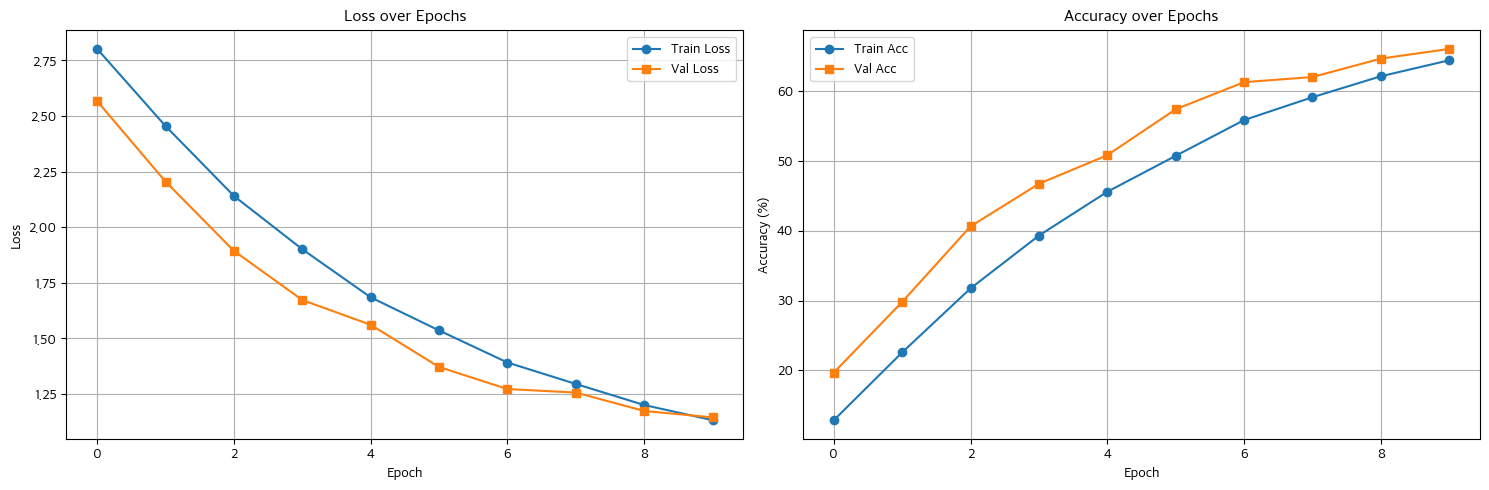


최종 결과
Train Acc: 64.44%
Val Acc: 66.07%
Best Val Loss: 1.1428


In [168]:
# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot([acc*100 for acc in train_accs], label='Train Acc', marker='o')
axes[1].plot([acc*100 for acc in val_accs], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 최종 결과
print("\n" + "="*70)
print("최종 결과")
print("="*70)
print(f"Train Acc: {train_accs[-1]*100:.2f}%")
print(f"Val Acc: {val_accs[-1]*100:.2f}%")
print(f"Best Val Loss: {best_val_loss:.4f}")
print("="*70)

In [169]:
# 저장된 모델 불러오기
print("저장된 모델 불러오는 중...")

model = BasicRNN(vocab_size=VOCAB_SIZE,
                 embedding_dim=EMBEDDING_DIM,
                 hidden_dim=HIDDEN_DIM,
                 output_dim=OUTPUT_DIM,
                 n_layers=N_LAYERS,
                 dropout=DROPOUT,
                 bidirectional=BIDIRECTIONAL
                 ).to(DEVICE)


# 가중치 로드
model.load_state_dict(torch.load('best_whole_model.pt', map_location=DEVICE))
print("✓ 모델 로드 완료!")

# 추가 학습
N_ADDITIONAL_EPOCHS = 20
best_val_loss = float('inf')

print("\n추가 학습 시작!")
print("="*70)

for epoch in range(N_ADDITIONAL_EPOCHS):
    print(f"\nEpoch {epoch+1}/{N_ADDITIONAL_EPOCHS}")

    train_loss, train_acc = train_epoch(model, WHOLE_TRAIN_DATALOADER)
    val_loss, val_acc = evaluate(model, WHOLE_VAL_DATALOADER)

    SCHEDULER.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_whole_model.pt")
        print("Best Model 저장 완료")

print("추가 학습 완료")

저장된 모델 불러오는 중...
✓ 모델 로드 완료!

추가 학습 시작!

Epoch 1/20


Evaluating: 100%|██████████| 121/121 [00:43<00:00,  2.76it/s]



Train Loss: 1.1115 | Train Acc: 65.39%
Val Loss: 1.1428 | Val Acc: 66.07%
Best Model 저장 완료

Epoch 2/20


Evaluating: 100%|██████████| 121/121 [00:44<00:00,  2.75it/s]



Train Loss: 1.1059 | Train Acc: 65.38%
Val Loss: 1.1428 | Val Acc: 66.07%

Epoch 3/20


...


Train Loss: 1.0995 | Train Acc: 65.37%
Val Loss: 1.1428 | Val Acc: 66.07%

Epoch 10/20


Evaluating: 100%|██████████| 121/121 [00:45<00:00,  2.66it/s]



Train Loss: 1.1146 | Train Acc: 65.04%
Val Loss: 1.1428 | Val Acc: 66.07%

Epoch 11/20


Training:   1%|▏         | 7/483 [00:03<04:24,  1.80it/s]


KeyboardInterrupt: 

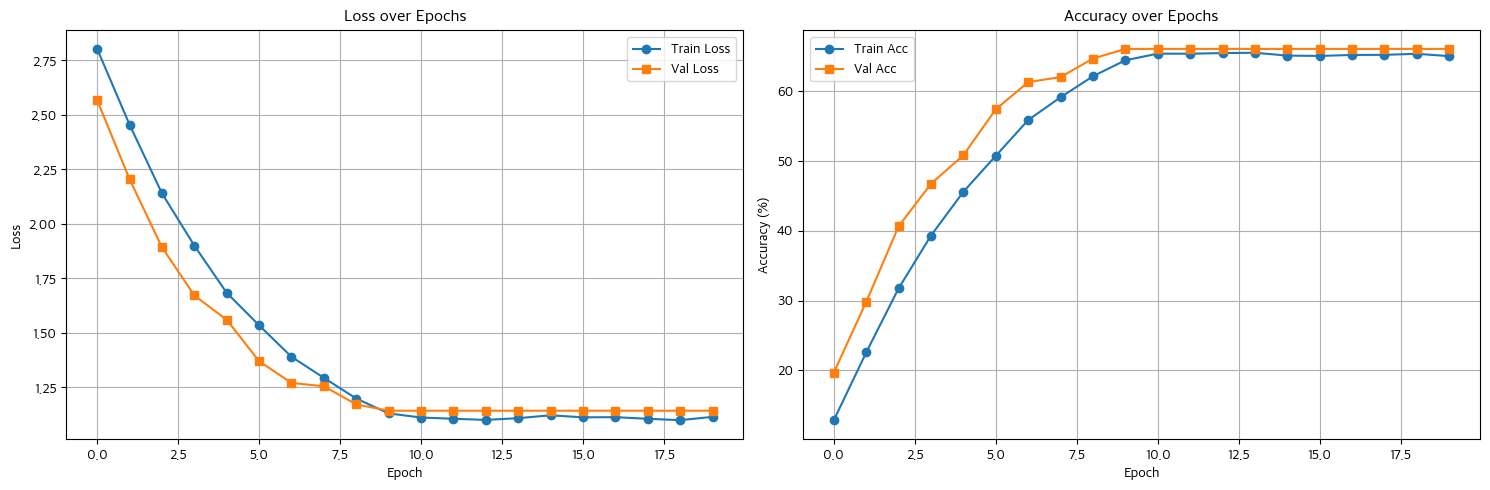


최종 결과
Train Acc: 65.04%
Val Acc: 66.07%
Best Val Loss: 1.1428


In [170]:
# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot([acc*100 for acc in train_accs], label='Train Acc', marker='o')
axes[1].plot([acc*100 for acc in val_accs], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 최종 결과
print("\n" + "="*70)
print("최종 결과")
print("="*70)
print(f"Train Acc: {train_accs[-1]*100:.2f}%")
print(f"Val Acc: {val_accs[-1]*100:.2f}%")
print(f"Best Val Loss: {best_val_loss:.4f}")
print("="*70)

### 클래스 분리 | 텍스트 분리

In [ ]:

# ==================== 계층형 학습 구성 ====================

HIERARCHY_STAGES = [
    {"name": "stage_lvl0", "levels": [0], "epochs": 10},
    {"name": "stage_lvl0_1", "levels": [0, 1], "epochs": 10},
    {"name": "stage_full", "levels": "category", "epochs": 10},
]
EARLY_STOP_PATIENCE = 3


class HierarchyStageDataset(Dataset):
    def __init__(self, base_dataset, indices, stage_targets):
        self.base_dataset = base_dataset
        self.indices = indices
        self.stage_targets = stage_targets

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        X, _ = self.base_dataset[base_idx]
        y = torch.tensor(self.stage_targets[base_idx], dtype=torch.long)
        return X, y


def extract_stage_key(chunk, stage_cfg):
    levels = stage_cfg["levels"]
    if levels == "category":
        return chunk["category"]

    tokens = []
    for level in levels:
        token = chunk["split_category"].get(level)
        if token is None:
            break
        tokens.append(token)
    return ".".join(tokens)


def build_stage_targets(base_dataset, stage_cfg):
    stage_keys = []
    for chunk in base_dataset.list:
        key = extract_stage_key(chunk, stage_cfg)
        if not key:
            key = "UNKNOWN"
        stage_keys.append(key)

    unique_keys = sorted(set(stage_keys))
    key_to_idx = {key: idx for idx, key in enumerate(unique_keys)}
    targets = [key_to_idx[key] for key in stage_keys]
    return targets, key_to_idx


In [ ]:

def build_weighted_sampler(stage_targets, subset_indices):
    labels = torch.tensor([stage_targets[idx] for idx in subset_indices], dtype=torch.long)
    class_counts = torch.bincount(labels)
    class_weights = torch.zeros_like(class_counts, dtype=torch.float)
    non_zero_mask = class_counts > 0
    class_weights[non_zero_mask] = 1.0 / class_counts[non_zero_mask].float()
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return sampler, class_weights


def build_stage_dataloaders(stage_targets, batch_size=64):
    indices = list(range(len(stage_targets)))
    train_idx, val_idx = train_test_split(
        indices,
        test_size=0.2,
        stratify=stage_targets,
        random_state=42,
    )

    train_dataset = HierarchyStageDataset(whole_dataset, train_idx, stage_targets)
    val_dataset = HierarchyStageDataset(whole_dataset, val_idx, stage_targets)

    sampler, class_weights = build_weighted_sampler(stage_targets, train_idx)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    return train_loader, val_loader, class_weights


def train_epoch_stage(model, dataloader, optimizer, criterion):
    model.train()
    epoch_loss = 0.0
    epoch_acc = 0.0

    for Xs, ys in tqdm(dataloader, desc="Stage Training", leave=False):
        Xs = Xs.to(DEVICE)
        ys = ys.to(DEVICE)

        optimizer.zero_grad()
        preds = model(Xs)
        loss = criterion(preds, ys)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += calculate_accuracy(preds, ys).item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


def evaluate_stage(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0.0
    epoch_acc = 0.0

    with torch.no_grad():
        for Xs, ys in tqdm(dataloader, desc="Stage Evaluating", leave=False):
            Xs = Xs.to(DEVICE)
            ys = ys.to(DEVICE)

            preds = model(Xs)
            loss = criterion(preds, ys)
            epoch_loss += loss.item()
            epoch_acc += calculate_accuracy(preds, ys).item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


def run_hierarchical_finetuning(base_model, base_dataset, stages_config, batch_size=64):
    model = copy.deepcopy(base_model).to(DEVICE)
    stage_histories = []

    for stage_cfg in stages_config:
        stage_targets, label_map = build_stage_targets(base_dataset, stage_cfg)
        train_loader, val_loader, class_weights = build_stage_dataloaders(stage_targets, batch_size=batch_size)

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, len(label_map)).to(DEVICE)

        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )
        criterion = nn.CrossEntropyLoss()

        ckpt_path = os.path.join(DATA_DIR, f"best_{stage_cfg['name']}_model.pt")
        best_val_loss = float("inf")
        patience_counter = 0
        resume_message = "저장된 체크포인트 없음"

        if os.path.exists(ckpt_path):
            checkpoint = torch.load(ckpt_path, map_location=DEVICE)
            prev_label_map = checkpoint.get("label_map")
            if prev_label_map == label_map:
                model.load_state_dict(checkpoint["model_state_dict"])
                if "optimizer_state_dict" in checkpoint:
                    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
                if "scheduler_state_dict" in checkpoint:
                    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
                best_val_loss = checkpoint.get("val_loss", float("inf"))
                resume_message = f"기존 체크포인트 로드 (epoch {checkpoint.get('epoch', -1)})"
            else:
                resume_message = "체크포인트 라벨 구성 불일치로 무시"

        history = {
            "stage": stage_cfg["name"],
            "label_map": label_map,
            "class_weights": class_weights.tolist(),
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
        }

        print(f"[{stage_cfg['name']}] classes: {len(label_map)} | epochs: {stage_cfg['epochs']}")
        print(f"· checkpoint: {ckpt_path}")
        print(f"· resume: {resume_message}")

        for epoch in range(stage_cfg["epochs"]):
            train_loss, train_acc = train_epoch_stage(model, train_loader, optimizer, criterion)
            val_loss, val_acc = evaluate_stage(model, val_loader, criterion)
            scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            print(
                f"Epoch {epoch+1}/{stage_cfg['epochs']} - "
                f"Train {train_loss:.4f} ({train_acc*100:.2f}%) | "
                f"Val {val_loss:.4f} ({val_acc*100:.2f}%)"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(
                    {
                        "stage": stage_cfg["name"],
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "scheduler_state_dict": scheduler.state_dict(),
                        "val_loss": val_loss,
                        "val_acc": val_acc,
                        "label_map": label_map,
                    },
                    ckpt_path,
                )
                print("Best Model 저장 완료")
            else:
                patience_counter += 1
                if patience_counter >= EARLY_STOP_PATIENCE:
                    print("조기 종료: 개선 없음")
                    break

        if os.path.exists(ckpt_path):
            checkpoint = torch.load(ckpt_path, map_location=DEVICE)
            if checkpoint.get("label_map") == label_map:
                model.load_state_dict(checkpoint["model_state_dict"])

        stage_histories.append(history)
        clean_cache()

    return model, stage_histories


In [ ]:

# 계층형 파인튜닝 실행
hierarchical_model, hierarchical_histories = run_hierarchical_finetuning(
    base_model=MODEL,
    base_dataset=whole_dataset,
    stages_config=HIERARCHY_STAGES,
    batch_size=64,
)


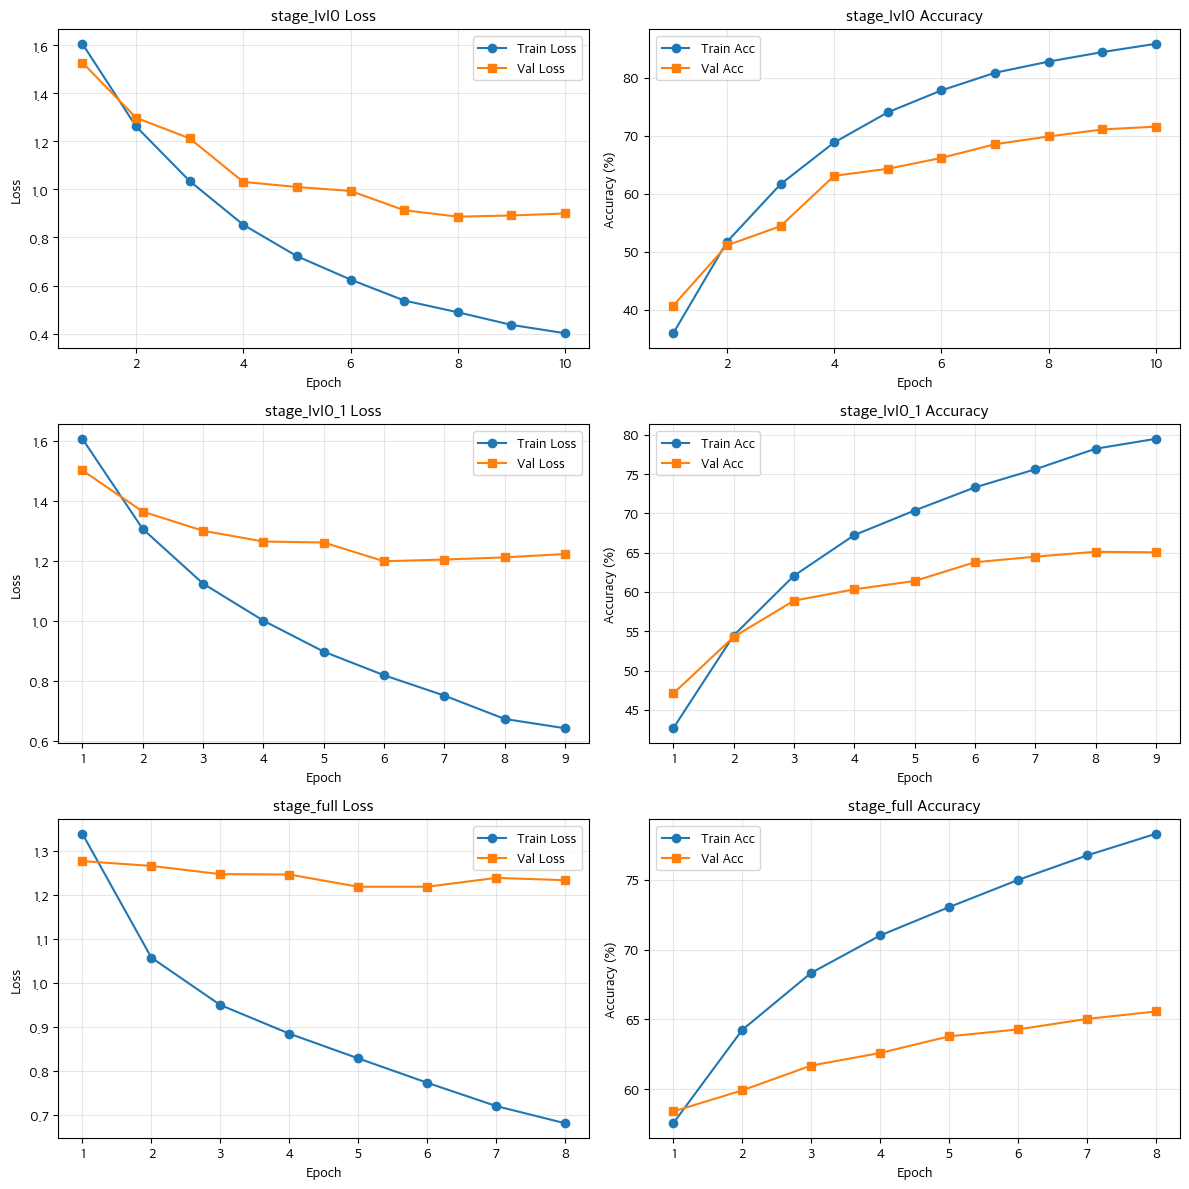

stage_full Heatmap Eval: 100%|██████████| 135/135 [00:39<00:00,  3.38it/s]


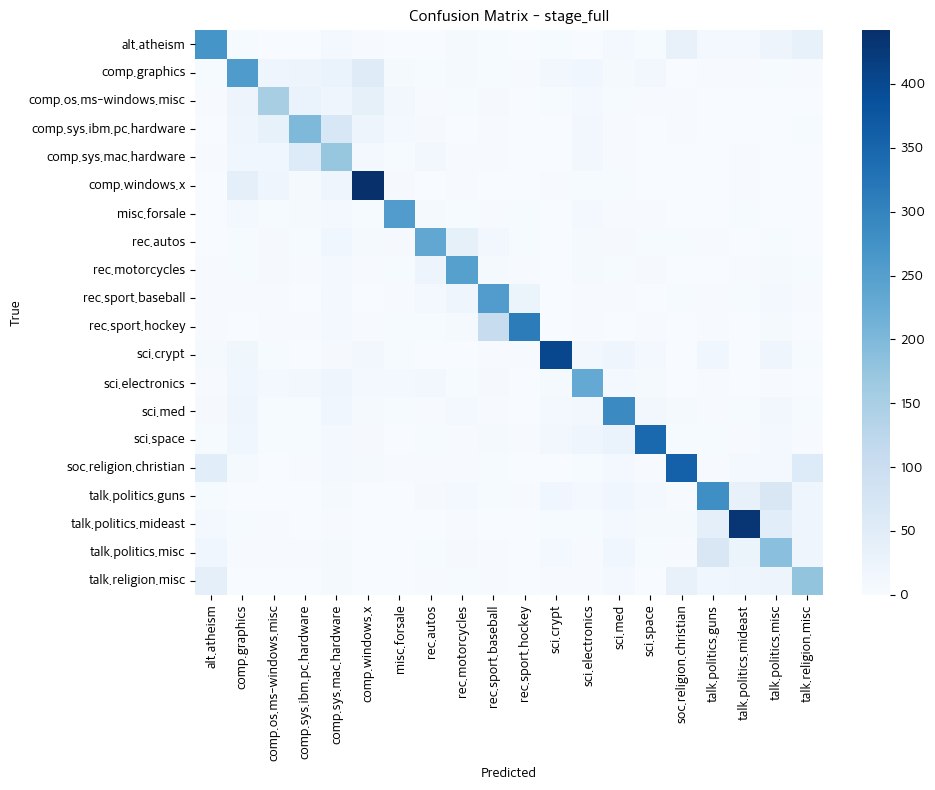

In [74]:

# 계층형 학습 결과 시각화 및 히트맵
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_hierarchy_histories(histories):
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    for ax_pair, history in zip(axes, histories):
        epochs = range(1, len(history["train_loss"]) + 1)
        ax_loss, ax_acc = ax_pair
        ax_loss.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
        ax_loss.plot(epochs, history["val_loss"], label="Val Loss", marker="s")
        ax_loss.set_title(f"{history['stage']} Loss")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)

        ax_acc.plot(epochs, [acc * 100 for acc in history["train_acc"]], label="Train Acc", marker="o")
        ax_acc.plot(epochs, [acc * 100 for acc in history["val_acc"]], label="Val Acc", marker="s")
        ax_acc.set_title(f"{history['stage']} Accuracy")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy (%)")
        ax_acc.legend()
        ax_acc.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_stage_confusion_heatmap(model, dataset, stage_cfg, batch_size=64):
    stage_targets, label_map = build_stage_targets(dataset, stage_cfg)
    indices = list(range(len(stage_targets)))
    _, val_idx = train_test_split(
        indices,
        test_size=0.2,
        stratify=stage_targets,
        random_state=42,
    )
    val_dataset = HierarchyStageDataset(dataset, val_idx, stage_targets)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for Xs, ys in tqdm(val_loader, desc=f"{stage_cfg['name']} Heatmap Eval"):
            Xs = Xs.to(DEVICE)
            ys = ys.to(DEVICE)
            logits = model(Xs)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().tolist())
            targets.extend(ys.cpu().tolist())

    labels = list(range(len(label_map)))
    cm = confusion_matrix(targets, preds, labels=labels)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix - {stage_cfg['name']}")
    tick_labels = [label for label, _ in sorted(label_map.items(), key=lambda x: x[1])]
    ax.set_xticks([i + 0.5 for i in range(len(labels))])
    ax.set_xticklabels(tick_labels, rotation=90)
    ax.set_yticks([i + 0.5 for i in range(len(labels))])
    ax.set_yticklabels(tick_labels, rotation=0)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()


plot_hierarchy_histories(hierarchical_histories)
plot_stage_confusion_heatmap(
    hierarchical_model,
    whole_dataset,
    HIERARCHY_STAGES[-1],
    batch_size=64,
)


[실험 모드] raw


raw Eval: 100%|██████████| 36/36 [00:53<00:00,  1.47s/it]


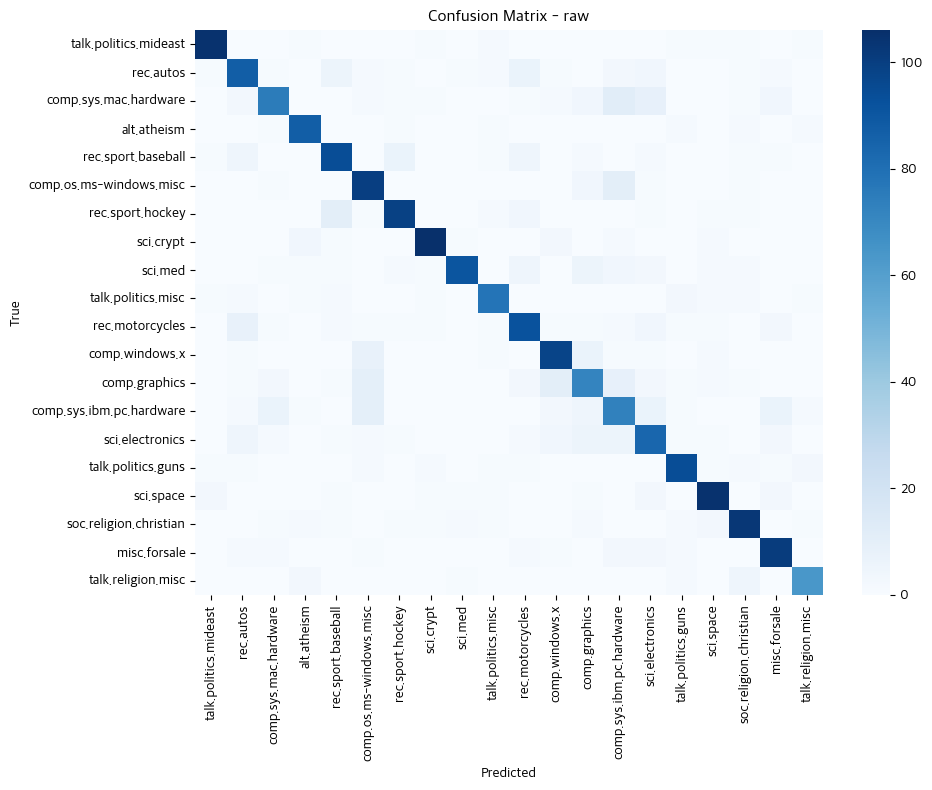

                          precision    recall  f1-score   support

   talk.politics.mideast       0.94      0.93      0.93       113
               rec.autos       0.74      0.73      0.74       119
   comp.sys.mac.hardware       0.79      0.65      0.71       115
             alt.atheism       0.87      0.91      0.89        96
      rec.sport.baseball       0.78      0.79      0.78       119
 comp.os.ms-windows.misc       0.72      0.85      0.78       118
        rec.sport.hockey       0.87      0.82      0.85       120
               sci.crypt       0.92      0.89      0.91       119
                 sci.med       0.94      0.76      0.84       119
      talk.politics.misc       0.86      0.84      0.85        93
         rec.motorcycles       0.75      0.77      0.76       120
          comp.windows.x       0.79      0.82      0.81       119
           comp.graphics       0.65      0.62      0.63       117
comp.sys.ibm.pc.hardware       0.58      0.62      0.60       118
         

whole Eval: 100%|██████████| 135/135 [00:39<00:00,  3.40it/s]


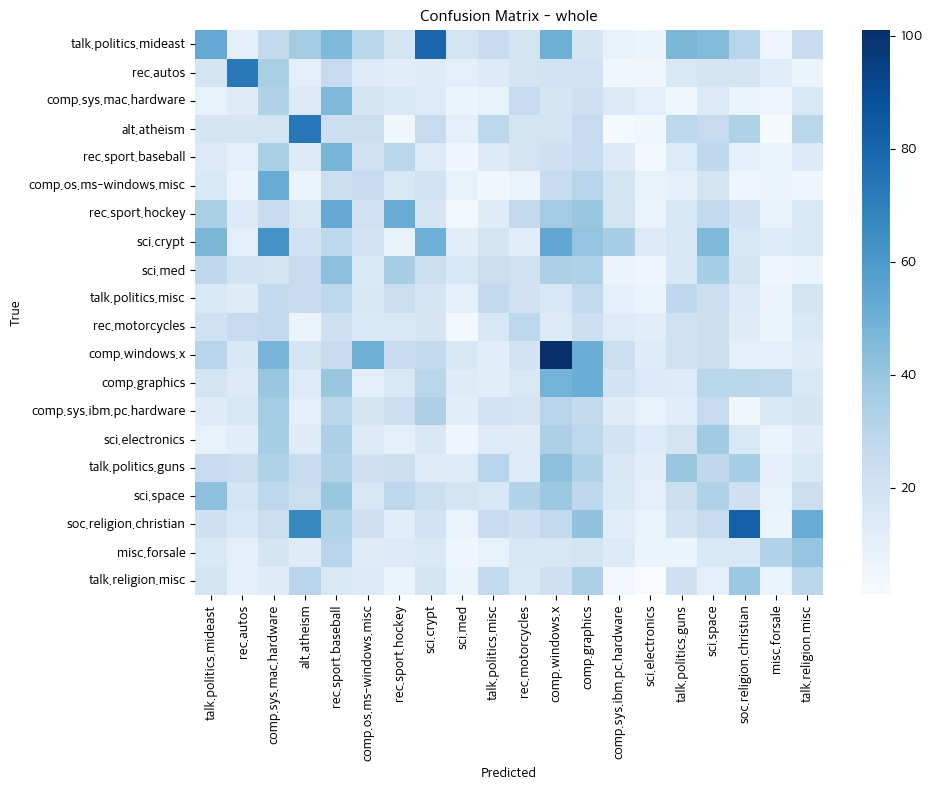

                          precision    recall  f1-score   support

   talk.politics.mideast       0.11      0.09      0.10       604
               rec.autos       0.20      0.20      0.20       369
   comp.sys.mac.hardware       0.05      0.10      0.07       321
             alt.atheism       0.16      0.17      0.16       437
      rec.sport.baseball       0.07      0.13      0.09       369
 comp.os.ms-windows.misc       0.06      0.08      0.07       324
        rec.sport.hockey       0.13      0.11      0.12       474
               sci.crypt       0.10      0.09      0.10       549
                 sci.med       0.08      0.04      0.05       438
      talk.politics.misc       0.07      0.07      0.07       381
         rec.motorcycles       0.07      0.08      0.08       347
          comp.windows.x       0.15      0.18      0.16       560
           comp.graphics       0.08      0.11      0.09       480
comp.sys.ibm.pc.hardware       0.04      0.03      0.04       391
         

whole_class_chunked Eval: 100%|██████████| 135/135 [00:39<00:00,  3.40it/s]


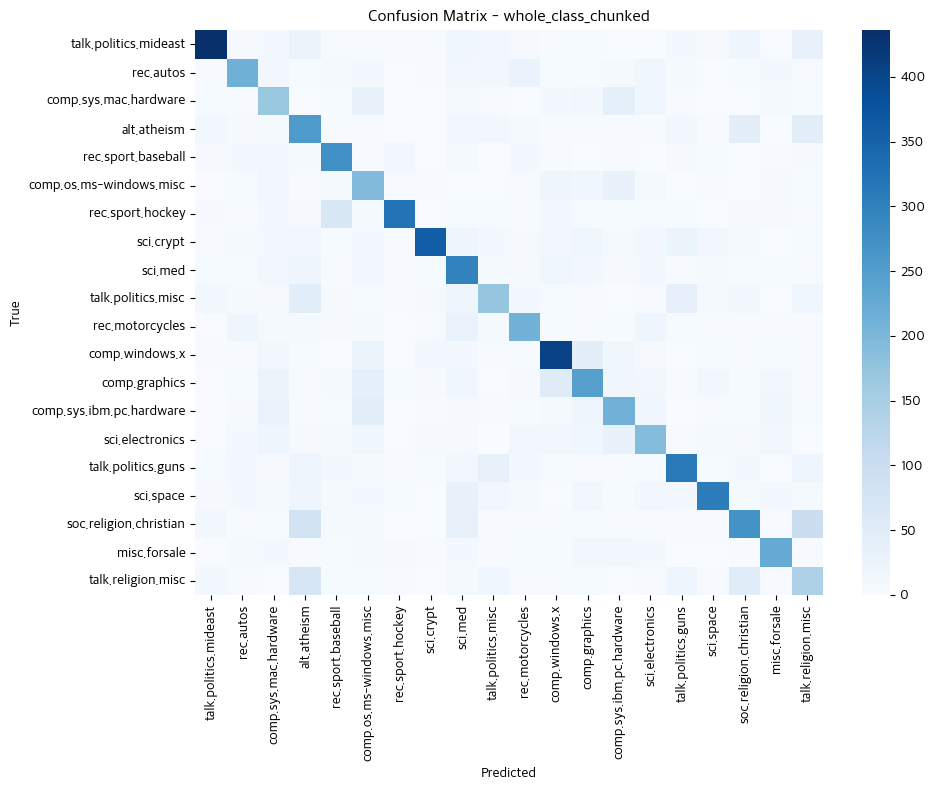

                          precision    recall  f1-score   support

   talk.politics.mideast       0.83      0.72      0.77       604
               rec.autos       0.63      0.58      0.60       369
   comp.sys.mac.hardware       0.44      0.53      0.48       321
             alt.atheism       0.42      0.59      0.49       437
      rec.sport.baseball       0.63      0.74      0.68       369
 comp.os.ms-windows.misc       0.43      0.60      0.50       324
        rec.sport.hockey       0.87      0.68      0.76       474
               sci.crypt       0.87      0.65      0.75       549
                 sci.med       0.53      0.68      0.59       438
      talk.politics.misc       0.53      0.45      0.49       381
         rec.motorcycles       0.61      0.61      0.61       347
          comp.windows.x       0.69      0.72      0.71       560
           comp.graphics       0.55      0.51      0.53       480
comp.sys.ibm.pc.hardware       0.51      0.54      0.53       391
         

In [73]:

# 기존 실험 모드 결과 시각화 (혼동 행렬 포함)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


def load_model_from_checkpoint(checkpoint_path):
    model = BasicRNN(
        vocab_size=VOCAB_SIZE,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
        bidirectional=BIDIRECTIONAL,
    ).to(DEVICE)
    if not os.path.exists(checkpoint_path):
        print(f"[경고] 체크포인트 없음: {checkpoint_path}")
        return None
    state = torch.load(checkpoint_path, map_location=DEVICE)
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    else:
        model.load_state_dict(state)
    model.eval()
    return model


def plot_confusion_heatmap(model, dataloader, title):
    preds, targets = [], []
    with torch.no_grad():
        for Xs, ys in tqdm(dataloader, desc=f"{title} Eval"):
            Xs = Xs.to(DEVICE)
            ys = ys.to(DEVICE)
            logits = model(Xs)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().tolist())
            targets.extend(ys.cpu().tolist())
    labels = sorted(whole_class_map_by_num.keys())
    cm = confusion_matrix(targets, preds, labels=labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix - {title}")
    tick_labels = [whole_class_map_by_num[idx] for idx in labels]
    ax.set_xticks([i + 0.5 for i in range(len(labels))])
    ax.set_xticklabels(tick_labels, rotation=90)
    ax.set_yticks([i + 0.5 for i in range(len(labels))])
    ax.set_yticklabels(tick_labels, rotation=0)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

    report = classification_report(targets, preds, target_names=tick_labels, zero_division=0)
    print(report)


experiment_visual_configs = []
if 'RAW_VAL_DATALOADER' in globals():
    experiment_visual_configs.append({
        "name": "raw",
        "checkpoint": os.path.join(DATA_DIR, "best_raw_model.pt"),
        "val_loader": RAW_VAL_DATALOADER,
    })
if 'WHOLE_VAL_DATALOADER' in globals():
    experiment_visual_configs.append({
        "name": "whole",
        "checkpoint": os.path.join(DATA_DIR, "best_whole_model.pt"),
        "val_loader": WHOLE_VAL_DATALOADER,
    })
if os.path.exists(os.path.join(DATA_DIR, "best_whole_class_chunked_model.pt")) and 'WHOLE_VAL_DATALOADER' in globals():
    experiment_visual_configs.append({
        "name": "whole_class_chunked",
        "checkpoint": os.path.join(DATA_DIR, "best_whole_class_chunked_model.pt"),
        "val_loader": WHOLE_VAL_DATALOADER,
    })

for config in experiment_visual_configs:
    print(f"[실험 모드] {config['name']}")
    model = load_model_from_checkpoint(config["checkpoint"])
    if model is None:
        continue
    plot_confusion_heatmap(model, config["val_loader"], title=config["name"])
